# 🏦 Loan Default Risk Analysis — Lending Club

## Executive Summary

This project analyzes **230,604 Lending Club loans** (sampled from a 2.26M record dataset) to identify what drives borrowers to default, and delivers actionable risk segmentation recommendations for a lending institution.

### What I Did
- Cleaned a real-world financial dataset with **145 features and 25%+ missing data**, reducing it to 75 clean, meaningful features
- Performed comprehensive exploratory analysis across loan grades, interest rates, income levels, debt-to-income ratios, credit utilization, and loan purposes
- Engineered **7 new business-relevant features** including credit utilization tiers, DTI risk categories, and loan-to-income ratios
- Built a **Logistic Regression model** to predict loan default with an AUC of **0.7035**
- Produced a grade-wise risk segmentation report with specific lending strategy recommendations

### Key Findings
| Finding | Detail |
|---------|--------|
| **Grade is the #1 predictor** | Grade A loans default at 6.2%, Grade G at 49.7% — an 8x increase |
| **Interest rate confirms risk** | Defaulted loans have median interest rate of 15.05% vs 12.29% for paid loans |
| **Small business loans are riskiest** | 29.8% default rate — highest among all loan purposes |
| **DTI above 25 is a red flag** | Default rate jumps to 25-32% for high-DTI borrowers |
| **Credit utilization matters** | Maxed-out borrowers default at 27.1% vs 16.1% for low utilization |
| **Higher income helps, but isn't enough** | Median income gap is only $5K ($65K vs $60K) — income alone is a weak predictor |

### Challenges Faced
1. **Massive missing data** — 111 out of 145 columns had missing values, with 46 columns over 40% empty. Required careful decisions on what to drop vs impute.
2. **Data leakage risk** — 15 columns contained post-loan information (total payments, recoveries) that would have inflated model performance artificially. Identified and removed all of them.
3. **Class imbalance** — Only 20% of loans defaulted, causing the model to be biased toward predicting "Fully Paid." The 80% accuracy is misleading; AUC (0.70) is the more honest metric.
4. **Outlier handling** — Annual income ranged up to $9.5M, DTI had values of 999 and -1. Required capping at reasonable thresholds based on EDA findings.
5. **Feature redundancy** — Several feature pairs had 0.85-0.98 correlation (multicollinearity), requiring careful selection to avoid model instability.

### Model Results
| Metric | Value | Interpretation |
|--------|-------|----------------|
| Accuracy | 80.0% | Misleading due to class imbalance — model mostly predicts "Fully Paid" |
| ROC-AUC | 0.7035 | Model meaningfully ranks borrowers by risk, significantly better than random (0.50) |
| Precision (Default) | 54% | When the model predicts default, it's right 54% of the time |
| Recall (Default) | 6% | Model catches only 6% of actual defaults — conservative threshold |

### Business Recommendation
- **Grades A-B (Safe Zone):** Approve with standard terms — 6-14% default rate
- **Grade C (Caution Zone):** Approve with income verification — 23% default rate
- **Grades D-E (Restriction Zone):** Tighten criteria, require collateral — 31-39% default rate
- **Grades F-G (Danger Zone):** Near coin-flip default rates (45-50%) — deny or require substantial collateral

### Tech Stack
Python, Pandas, NumPy, Matplotlib, Seaborn, Plotly, Scikit-learn, Google Colab

---

## Detailed Analysis Begins Below

In [1]:
# IMPORT LIBRARIES

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ML (we'll use these on Day 3)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)
from sklearn.preprocessing import StandardScaler

# Settings
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 80)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


In [2]:
# LOAD DATASET FROM GOOGLE DRIVE

# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("✓ Google Drive mounted!")

Mounted at /content/drive
✓ Google Drive mounted!


In [3]:
# Step 2: Load the CSV file
df = pd.read_csv('/content/drive/MyDrive/projects/loan.csv', low_memory=False)

print(f"✓ Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

✓ Dataset loaded successfully!
Shape: 2,260,668 rows × 145 columns
Memory usage: 5554.2 MB


In [4]:
# SAMPLE DATASET FOR EFFICIENT ANALYSIS

# Full dataset has 2.26M rows — too large for Colab's free RAM.
# We'll take a stratified random sample of 400K rows.
# This preserves the original distribution of loan outcomes.

df = df.sample(n=400_000, random_state=42)
df = df.reset_index(drop=True)

print(f"✓ Sampled to {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

✓ Sampled to 400,000 rows × 145 columns
Memory usage: 982.8 MB


In [5]:
# INITIAL DATA INSPECTION

# See the first 5 rows
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,...,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,35000,35000,35000.0,36 months,12.12,1164.51,B,B3,Legacy Physicians Group,< 1 year,RENT,90000.0,Verified,Jun-2013,Fully Paid,n,NaN,NaN,debt_consolidation,Hospital Debt,775xx,TX,3.51,0.0,Nov-1997,0.0,26.0,NaN,14.0,0.0,1347,8.1,22.0,w,0.00,0.00,36606.090000,36606.09,...,0.0,0.0,99068.0,81768.0,13400.0,82368.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000.0,60 months,10.75,648.54,B,B4,Director of nursing,2 years,RENT,100000.0,Verified,Apr-2016,Current,n,NaN,NaN,credit_card,Credit card refinancing,782xx,TX,22.85,0.0,Jun-2011,2.0,NaN,NaN,17.0,0.0,29780,52.7,25.0,f,14987.66,14987.66,22115.610000,22115.61,...,0.0,0.0,113051.0,65689.0,30800.0,56551.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,15000,15000,15000.0,36 months,7.49,466.53,A,A4,Partner,5 years,OWN,100000.0,Source Verified,Oct-2016,Fully Paid,n,NaN,NaN,small_business,Business,210xx,MD,6.71,0.0,Apr-1996,0.0,NaN,NaN,16.0,0.0,7425,10.3,25.0,w,0.00,0.00,16052.052943,16052.05,...,0.0,0.0,226524.0,17874.0,52300.0,15899.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,24000,24000,24000.0,60 months,21.15,651.31,E,E2,Einstein Bros. Bagels,5 years,RENT,58000.0,Source Verified,Sep-2013,Fully Paid,n,NaN,NaN,debt_consolidation,Debt Consolidation,282xx,NC,15.50,0.0,Aug-1998,0.0,NaN,NaN,10.0,0.0,24123,72.2,15.0,f,0.00,0.00,39078.323239,39078.32,...,0.0,0.0,38609.0,27496.0,20600.0,5209.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,14400,14400,14400.0,36 months,8.59,455.18,A,A5,Nurse practitioner,3 years,MORTGAGE,90000.0,Not Verified,Aug-2016,Current,n,NaN,NaN,debt_consolidation,Debt consolidation,658xx,MO,19.88,0.0,Dec-2003,0.0,41.0,NaN,19.0,0.0,16615,49.9,48.0,w,2663.68,2663.68,13648.530000,13648.53,...,0.0,0.0,141144.0,131564.0,20700.0,107844.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Column names, data types, and non-null counts
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Columns: 145 entries, id to settlement_term
dtypes: float64(105), int64(4), object(36)
memory usage: 442.5+ MB


In [7]:
# Statistical summary of numeric columns
df.describe().round(2)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,url,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,annual_inc_joint,dti_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,...,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,settlement_amount,settlement_percentage,settlement_term
count,0.0,0.0,400000.00,400000.00,400000.00,400000.00,400000.00,400000.00,0.0,399685.00,399995.00,399994.00,195177.00,64096.00,399995.00,399995.00,400000.00,399681.00,399995.00,400000.00,400000.00,400000.00,400000.00,400000.00,400000.00,400000.00,400000.00,400000.00,400000.00,399972.00,102770.00,400000.0,21510.00,21508.00,399995.00,387664.00,387664.00,246919.00,246920.00,246920.00,...,387664.00,389698.00,387664.00,387664.00,387664.00,387663.00,387664.00,389698.00,372886.00,387664.00,387664.00,387664.00,387638.00,386642.00,399763.00,399984.00,387664.00,391141.00,391141.00,387664.00,19212.00,19212.00,19212.00,19212.00,18901.00,19212.00,19212.00,19212.00,19212.00,6348.00,1849.0,1849.00,1849.0,1849.00,1487.00,1849.00,1849.00,5857.00,5857.00,5857.00
mean,NaN,NaN,15068.13,15063.14,15045.17,13.10,446.40,77977.17,NaN,18.86,0.31,0.58,34.59,72.36,11.63,0.20,16668.65,50.34,24.18,4459.06,4458.07,11838.01,11820.13,9307.99,2392.11,1.47,136.44,22.69,3370.13,0.02,44.15,1.0,123594.29,19.27,0.00,225.00,142364.02,0.93,2.78,0.68,...,5.64,4.77,7.73,8.42,8.26,14.01,5.58,11.64,0.00,0.00,0.08,2.08,94.11,42.44,0.13,0.05,178131.83,50976.53,23242.26,43688.06,33710.52,0.63,1.53,11.45,58.20,3.00,12.44,0.05,0.07,36.62,3.0,154.42,3.0,13.78,453.27,11521.05,195.54,5011.98,47.80,13.15
std,NaN,NaN,9192.71,9190.70,9194.18,4.83,267.10,73295.88,NaN,14.28,0.87,0.89,21.94,26.44,5.64,0.57,22848.76,24.73,11.97,7558.91,7557.96,9900.64,9895.35,8308.03,2675.35,11.81,735.35,129.76,5986.05,0.15,21.63,0.0,64613.03,7.84,0.07,2380.91,159702.52,1.14,2.98,0.92,...,3.39,3.04,4.72,7.35,4.69,8.05,3.30,5.64,0.03,0.05,0.50,1.83,9.05,36.20,0.37,0.37,180455.40,49541.96,23159.44,44816.97,28085.84,1.00,1.74,6.57,25.59,3.26,8.04,0.38,0.38,23.82,0.0,126.98,0.0,9.77,365.84,7501.56,205.28,3741.78,6.98,8.04
min,NaN,NaN,500.00,500.00,0.00,5.31,15.69,0.00,NaN,-1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.00,0.00,0.00,0.00,0.00,0.00,1.0,11000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.0,3.39,3.0,0.00,10.17,457.26,0.01,142.00,0.55,0.00
25%,NaN,NaN,8000.00,8000.00,8000.00,9.49,251.74,46000.00,NaN,11.93,0.00,0.00,16.00,55.00,8.00,0.00,5962.00,31.50,15.00,0.00,0.00,4270.19,4254.95,2847.51,695.25,0.00,0.00,0.00,309.55,0.00,27.00,1.0,83500.00,13.43,0.00,0.00,29230.00,0.00,1.00,0.00,...,3.00,3.00,4.00,3.00,5.00,8.00,3.00,8.00,0.00,0.00,0.00,1.00,91.30,0.00,0.00,0.00,50967.00,20981.00,8300.00,15000.00,15053.00,0.00,0.00,7.00,40.00,1.00,7.00,0.00,0.00,16.00,3.0,59.63,3.0,5.00,178.29,5636.91,41.66,2210.00,45.00,6.00
50%,NaN,NaN,13000.00,

In [8]:
# DATA QUALITY ASSESSMENT — MISSING VALUES

# Calculate missing values for each column
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing %', ascending=False)

# Show only columns that HAVE missing values
missing_cols = missing[missing['Missing Count'] > 0]
print(f"Columns with missing data: {len(missing_cols)} out of {df.shape[1]}")
print(f"Columns with NO missing data: {df.shape[1] - len(missing_cols)}")
print(f"\n{'='*60}")
print("TOP 30 COLUMNS BY MISSING DATA:")
print('='*60)
missing_cols.head(30)

Columns with missing data: 111 out of 145
Columns with NO missing data: 34

TOP 30 COLUMNS BY MISSING DATA:


,Missing Count,Missing %
id,400000,100.00
member_id,400000,100.00
url,400000,100.00
orig_projected_additional_accrued_interest,398513,99.63
hardship_amount,398151,99.54
hardship_dpd,398151,99.54
hardship_loan_status,398151,99.54
deferral_term,398151,99.54
hardship_end_date,398151,99.54
hardship_status,398151,99.54


In [9]:
# Visualize missing data — top 25 columns
top_missing = missing_cols.head(25)

fig = px.bar(top_missing, x='Missing %', y=top_missing.index,
             orientation='h', title='Top 25 Columns by Missing Data %',
             color='Missing %', color_continuous_scale='Reds',
             text='Missing %')
fig.update_layout(yaxis=dict(autorange='reversed'), height=700,
                  xaxis_title='Missing Percentage (%)',
                  yaxis_title='Column Name')
fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.show()

In [10]:
# IDENTIFY THE TARGET VARIABLE

# What are all the possible loan statuses?
print("All Loan Status Values:")
print("=" * 50)
print(df['loan_status'].value_counts())
print(f"\nTotal unique statuses: {df['loan_status'].nunique()}")

All Loan Status Values:
loan_status
Fully Paid                                             184147
Current                                                162761
Charged Off                                             46457
Late (31-120 days)                                       3897
In Grace Period                                          1603
Late (16-30 days)                                         658
Does not meet the credit policy. Status:Fully Paid        343
Does not meet the credit policy. Status:Charged Off       129
Default                                                     5
Name: count, dtype: int64

Total unique statuses: 9


In [11]:
# FILTER FOR CLEAR OUTCOMES ONLY

# Keep only loans with definitive outcomes
df_clean = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()

# Create binary target: 1 = Default (Charged Off), 0 = Fully Paid
df_clean['is_default'] = (df_clean['loan_status'] == 'Charged Off').astype(int)

print(f"Rows before filtering: {len(df):,}")
print(f"Rows after filtering:  {len(df_clean):,}")
print(f"Rows removed:          {len(df) - len(df_clean):,} (ambiguous/ongoing loans)")
print(f"\n{'='*50}")
print(f"Default Rate: {df_clean['is_default'].mean():.2%}")
print(f"Fully Paid:   {(df_clean['is_default'] == 0).sum():,} ({(df_clean['is_default'] == 0).mean():.1%})")
print(f"Charged Off:  {(df_clean['is_default'] == 1).sum():,} ({(df_clean['is_default'] == 1).mean():.1%})")

Rows before filtering: 400,000
Rows after filtering:  230,604
Rows removed:          169,396 (ambiguous/ongoing loans)

Default Rate: 20.15%
Fully Paid:   184,147 (79.9%)
Charged Off:  46,457 (20.1%)


In [12]:
# DROP COLUMNS — HIGH MISSING, IRRELEVANT, AND DATA LEAKAGE

# STEP 1: Drop columns with >40% missing data
high_missing = missing[missing['Missing %'] > 40].index.tolist()
print(f"Columns with >40% missing data: {len(high_missing)} → DROPPING ALL")

# STEP 2: Identify data leakage columns
# These contain information from AFTER the loan was issued.
# Using them would be like having the answer key during a test.
leakage_cols = [
    'funded_amnt',              # How much was funded (same as loan_amnt)
    'funded_amnt_inv',          # Funded by investors (same concept)
    'total_pymnt',              # Total payment received — POST-LOAN
    'total_pymnt_inv',          # Payment from investors — POST-LOAN
    'total_rec_prncp',          # Principal received — POST-LOAN
    'total_rec_int',            # Interest received — POST-LOAN
    'total_rec_late_fee',       # Late fees received — POST-LOAN
    'recoveries',               # Recovery after default — POST-LOAN
    'collection_recovery_fee',  # Collection fees — POST-LOAN
    'last_pymnt_d',             # Last payment date — POST-LOAN
    'last_pymnt_amnt',          # Last payment amount — POST-LOAN
    'last_credit_pull_d',       # Last credit check — POST-LOAN
    'out_prncp',                # Outstanding principal — POST-LOAN
    'out_prncp_inv',            # Outstanding principal investors — POST-LOAN
    'next_pymnt_d',             # Next payment date — POST-LOAN
]

# STEP 3: Identify irrelevant columns
irrelevant_cols = [
    'id', 'member_id',          # IDs — no predictive value
    'url',                      # URLs — empty anyway
    'desc',                     # Free text description
    'title',                    # Free text loan title
    'zip_code',                 # Too granular (first 3 digits only)
    'policy_code',              # Single value — no variation
    'loan_status',              # Already converted to is_default
    'sub_grade',                # Redundant with grade (too granular)
    'application_type',         # Mostly "Individual"
]

# COMBINE all columns to drop
all_drop = set(high_missing + leakage_cols + irrelevant_cols)

# Only drop columns that actually exist in our dataframe
all_drop = [col for col in all_drop if col in df_clean.columns]

print(f"Data leakage columns:    {len([c for c in leakage_cols if c in df_clean.columns])}")
print(f"Irrelevant columns:      {len([c for c in irrelevant_cols if c in df_clean.columns])}")
print(f"Total columns to drop:   {len(all_drop)}")

# DROP THEM
df_clean = df_clean.drop(columns=all_drop)

print(f"\n{'='*50}")
print(f"Columns BEFORE cleaning: 145")
print(f"Columns AFTER cleaning:  {df_clean.shape[1]}")
print(f"Rows:                    {df_clean.shape[0]:,}")
print(f"Memory usage:            {df_clean.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Columns with >40% missing data: 46 → DROPPING ALL
Data leakage columns:    15
Irrelevant columns:      10
Total columns to drop:   66

Columns BEFORE cleaning: 145
Columns AFTER cleaning:  80
Rows:                    230,604
Memory usage:            297.5 MB


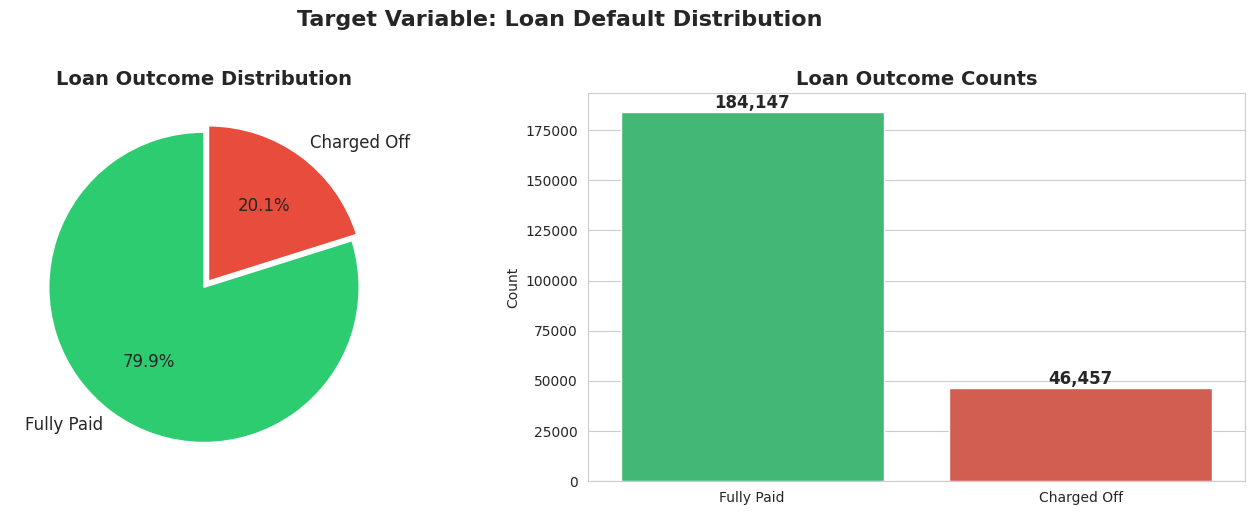

Key Insight: ~20% of loans defaulted — the dataset is moderately imbalanced.
This means our model will see 4 'Fully Paid' loans for every 1 'Charged Off' loan.


In [13]:
# UNIVARIATE ANALYSIS — TARGET VARIABLE

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Color scheme: Green = safe, Red = default
colors = ['#2ecc71', '#e74c3c']
labels = ['Fully Paid', 'Charged Off']
counts = [184147, 46457]

# PIE CHART
axes[0].pie(counts, labels=labels, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0, 0.05),
            textprops={'fontsize': 12})
axes[0].set_title('Loan Outcome Distribution', fontsize=14, fontweight='bold')

# BAR CHART with counts
sns.countplot(data=df_clean, x='is_default', palette=colors, ax=axes[1])
axes[1].set_xticklabels(labels)
axes[1].set_title('Loan Outcome Counts', fontsize=14, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Count')

# Add count labels on top of bars
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.suptitle('Target Variable: Loan Default Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Key Insight: ~20% of loans defaulted — the dataset is moderately imbalanced.")
print("This means our model will see 4 'Fully Paid' loans for every 1 'Charged Off' loan.")

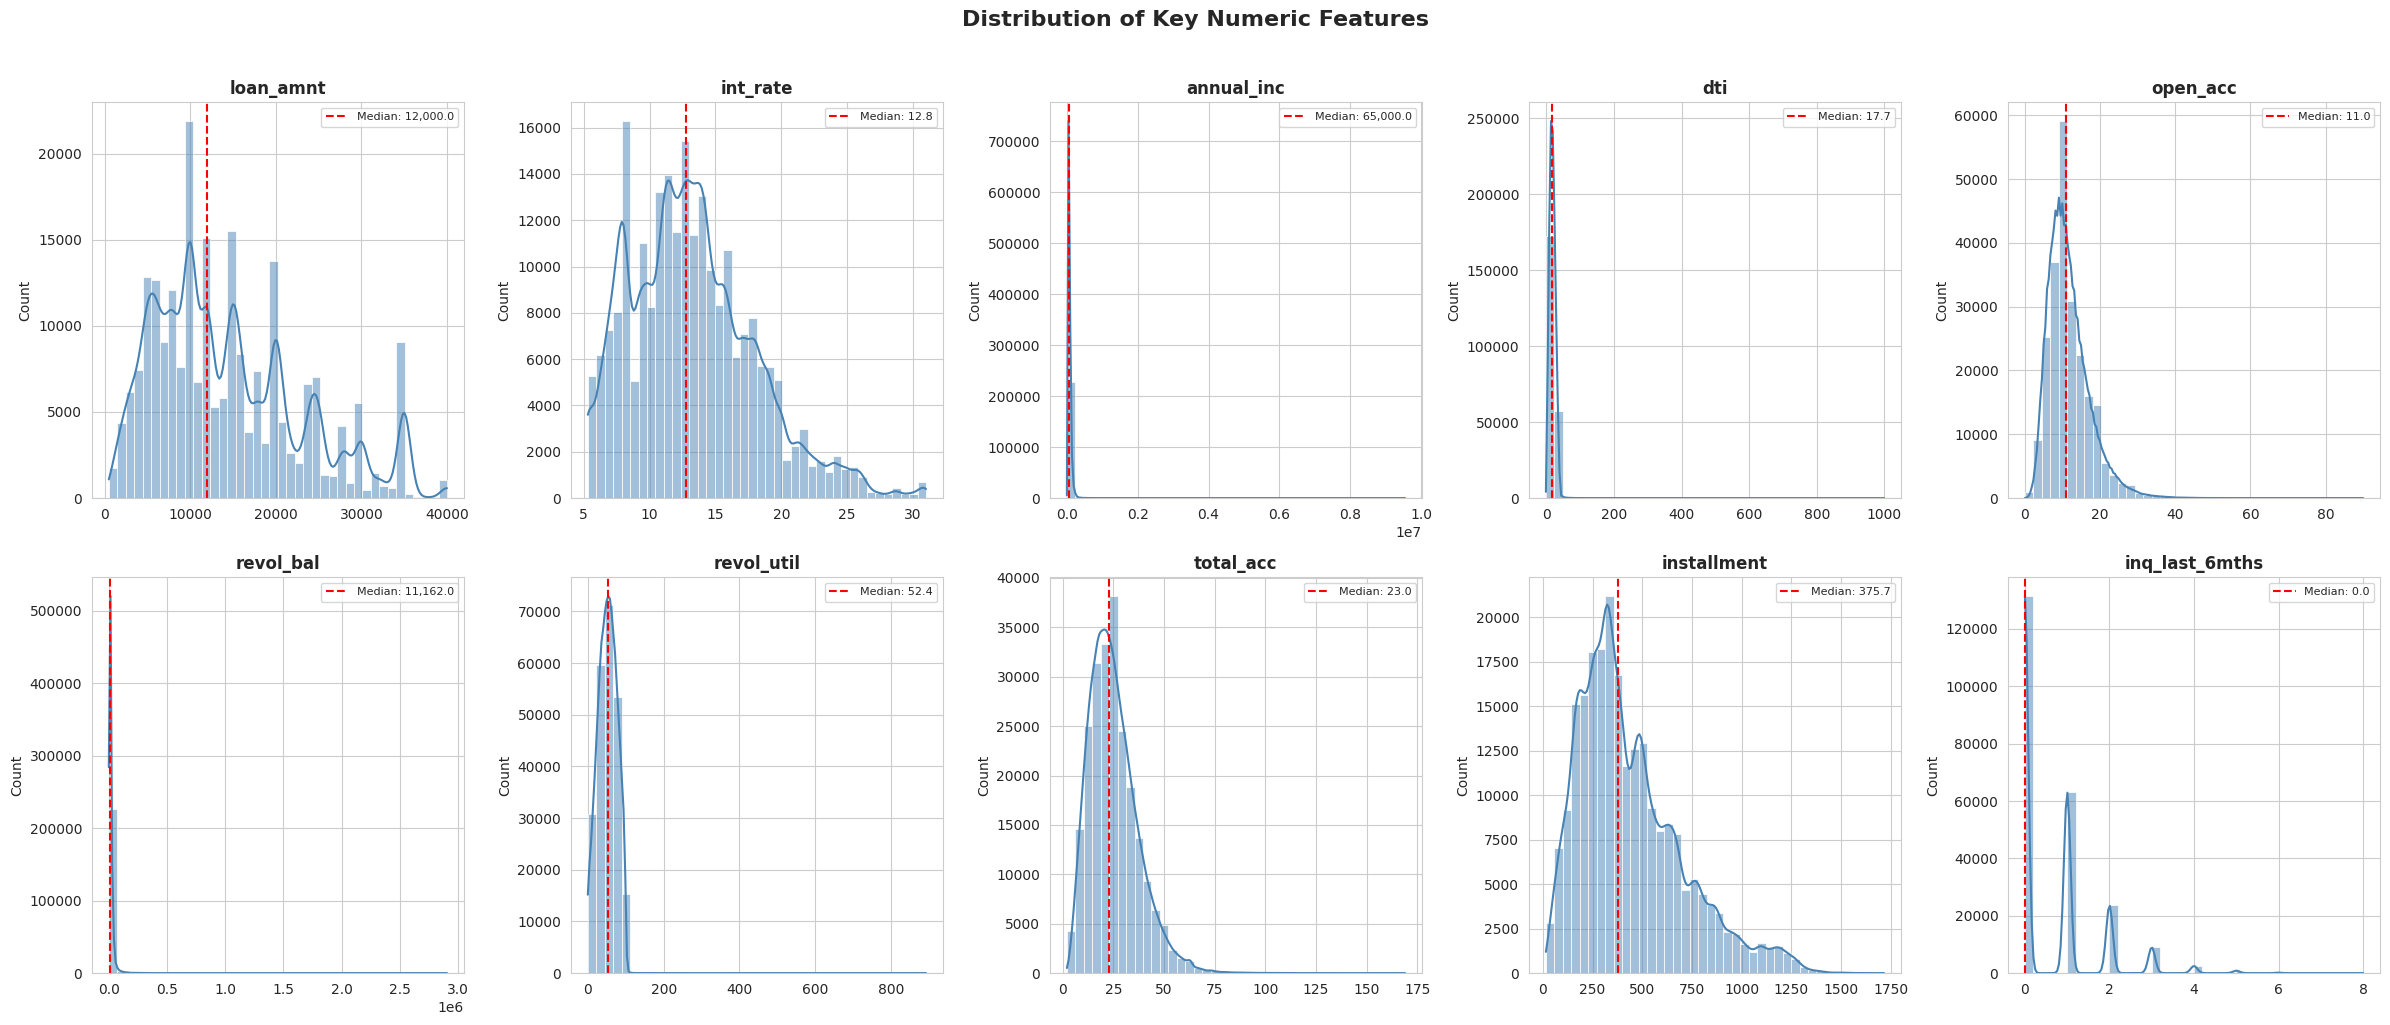


Summary Statistics:


,loan_amnt,int_rate,annual_inc,dti,open_acc,revol_bal,revol_util,total_acc,installment,inq_last_6mths
count,230604.00,230604.00,230604.00,230539.00,230604.00,230604.00,230474.00,230604.00,230604.00,230603.00
mean,14417.64,13.27,76301.22,18.30,11.62,16239.44,51.89,25.06,438.29,0.66
std,8696.94,4.76,74078.28,11.02,5.49,22724.38,24.57,12.00,261.04,0.94
min,500.00,5.31,0.00,-1.00,0.00,0.00,0.00,2.00,15.69,0.00
25%,8000.00,9.75,46000.00,11.83,8.00,5941.00,33.50,16.00,248.68,0.00
50%,12000.00,12.79,65000.00,17.66,11.00,11162.00,52.40,23.00,375.71,0.00
75%,20000.00,16.02,90000.00,24.06,14.00,19748.00,70.80,32.00,581.36,1.00
max,40000.00,30.99,9550000.00,999.00,90.00,2904836.00,892.30,169.00,1715.42,8.00


In [14]:
# UNIVARIATE ANALYSIS — KEY NUMERIC FEATURES

# Select the most important numeric columns to analyze
numeric_features = ['loan_amnt', 'int_rate', 'annual_inc', 'dti',
                    'open_acc', 'revol_bal', 'revol_util', 'total_acc',
                    'installment', 'inq_last_6mths']

# Only keep features that exist in our dataframe
numeric_features = [col for col in numeric_features if col in df_clean.columns]

fig, axes = plt.subplots(2, 5, figsize=(24, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.histplot(df_clean[col].dropna(), kde=True, ax=axes[i],
                 color='steelblue', bins=40)
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')

    # Add median line
    median_val = df_clean[col].median()
    axes[i].axvline(median_val, color='red', linestyle='--', linewidth=1.5,
                    label=f'Median: {median_val:,.1f}')
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('')

# Remove extra subplots if any
for j in range(len(numeric_features), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribution of Key Numeric Features',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print summary statistics for these features
print("\nSummary Statistics:")
print("=" * 70)
df_clean[numeric_features].describe().round(2)

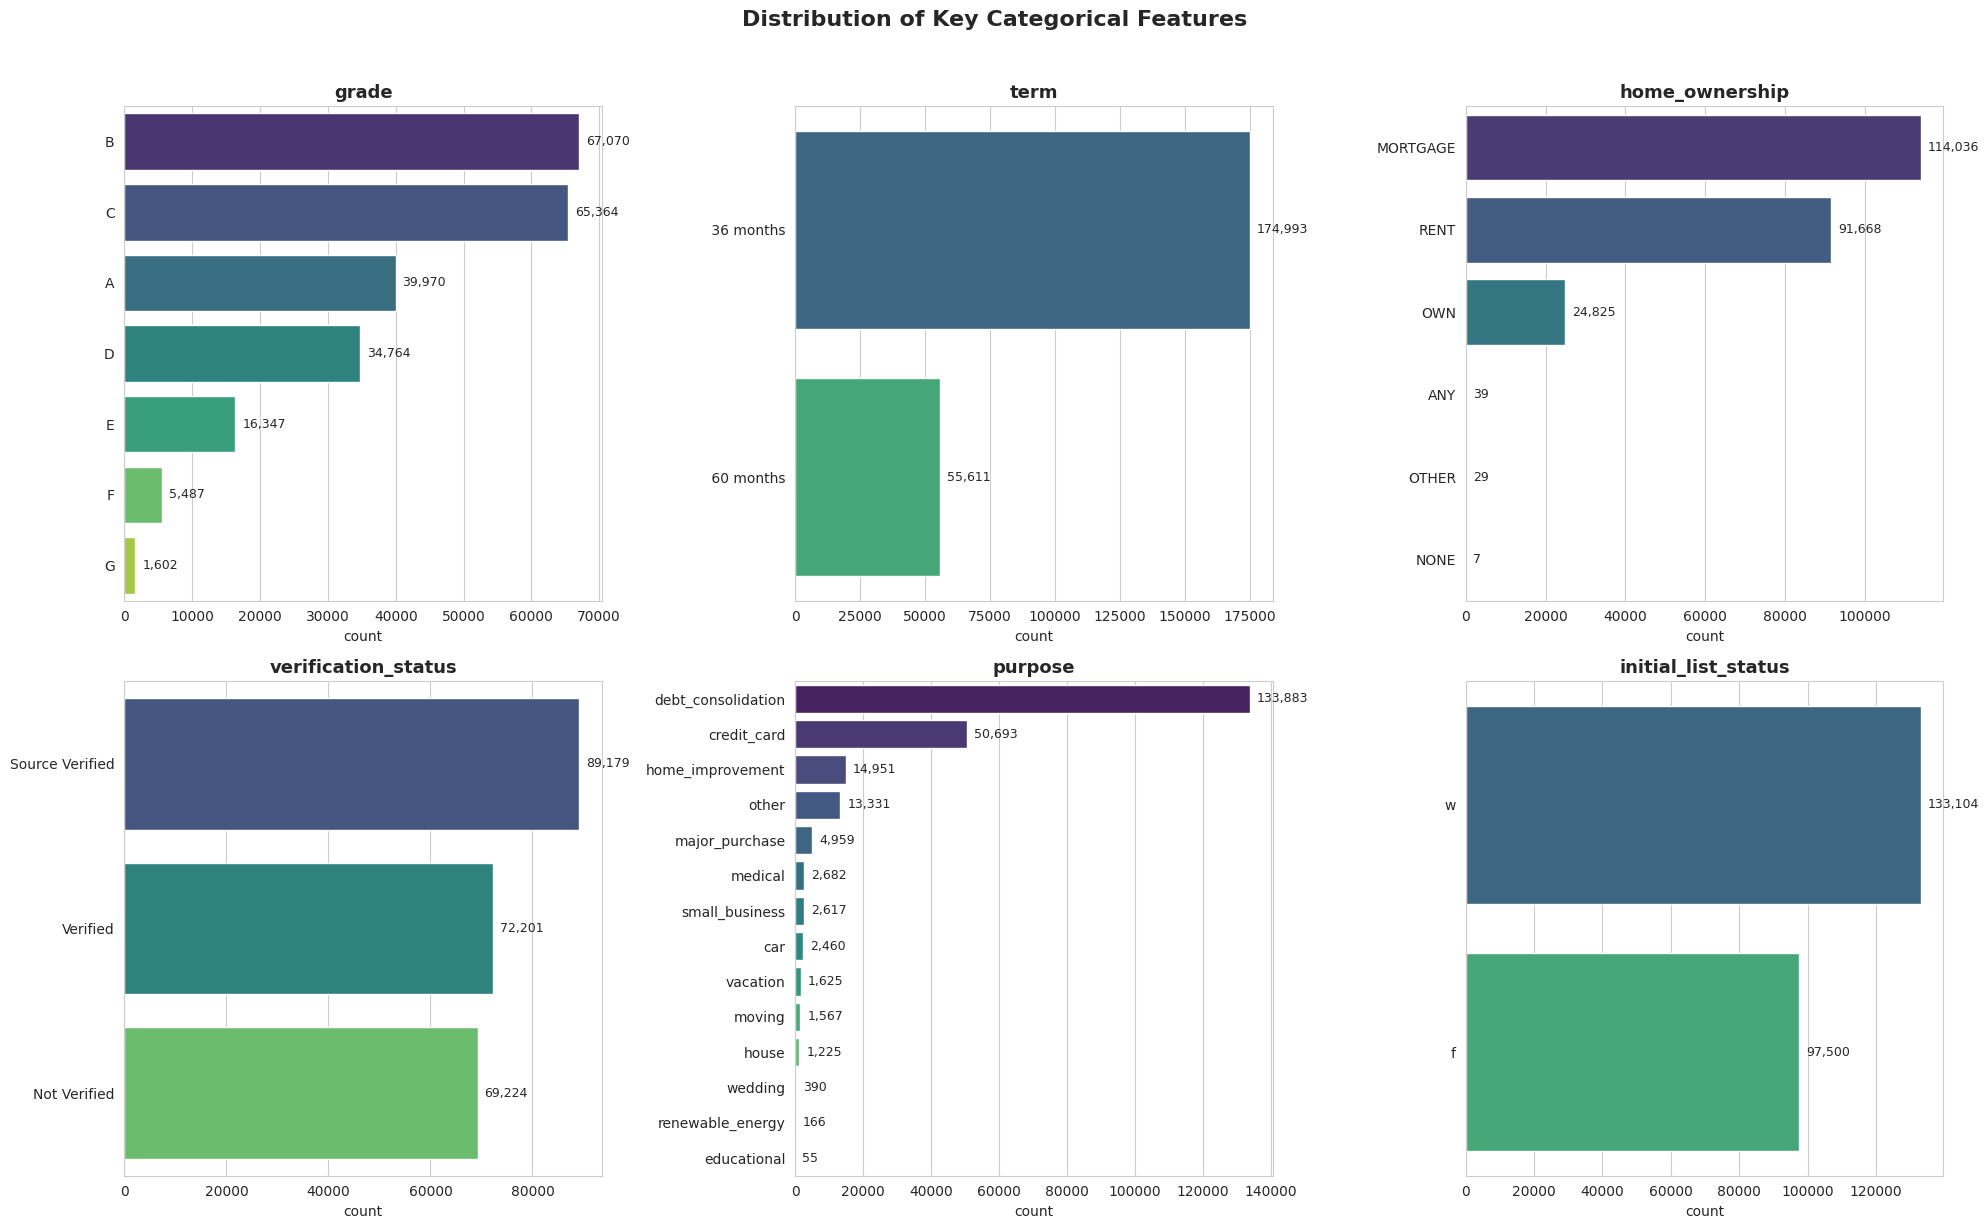

In [15]:
# UNIVARIATE ANALYSIS — KEY CATEGORICAL FEATURES

cat_features = ['grade', 'term', 'home_ownership', 'verification_status',
                'purpose', 'initial_list_status']

# Only keep features that exist
cat_features = [col for col in cat_features if col in df_clean.columns]

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

palette = 'viridis'

for i, col in enumerate(cat_features):
    # Order by frequency
    order = df_clean[col].value_counts().index
    sns.countplot(data=df_clean, y=col, order=order, palette=palette, ax=axes[i])
    axes[i].set_title(f'{col}', fontsize=13, fontweight='bold')
    axes[i].set_ylabel('')

    # Add count labels
    for p in axes[i].patches:
        width = p.get_width()
        axes[i].annotate(f'{int(width):,}',
                         (width, p.get_y() + p.get_height() / 2.),
                         ha='left', va='center', fontsize=9,
                         xytext=(5, 0), textcoords='offset points')

# Remove extra subplots if any
for j in range(len(cat_features), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribution of Key Categorical Features',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Day 1 EDA Summary

### Dataset Overview
- Original: 2.26M loans, 145 features → Sampled 400K rows
- After filtering for clear outcomes (Fully Paid / Charged Off): **230,604 loans**
- After dropping high-missing, leakage, and irrelevant columns: **80 features remaining**

### Target Variable
- **Default rate: 20.15%** (46,457 charged off vs 184,147 fully paid)
- Dataset is moderately imbalanced (4:1 ratio)

### Key Observations from Univariate Analysis
- **Loan amounts** cluster at round numbers ($5K, $10K, $15K, $20K)
- **Interest rates** follow a roughly normal distribution, median 12.8%
- **Annual income** is heavily right-skewed with extreme outliers (up to $9.5M)
- **DTI** has suspicious values (min: -1, max: 999) — needs cleaning
- **Debt consolidation** is the dominant loan purpose (58% of all loans)
- **Grades B and C** are most common; high-risk grades (F, G) are rare
- **36-month terms** outnumber 60-month terms ~3:1

### Next Steps (Day 2)
- Bivariate analysis: How does each feature relate to default?
- Clean remaining data quality issues (DTI outliers, income outliers)
- Feature engineering: Create risk tiers and derived features

In [16]:
# BIVARIATE ANALYSIS — DEFAULT RATE BY LOAN GRADE

grade_default = df_clean.groupby('grade')['is_default'].agg(['mean', 'count']).reset_index()
grade_default.columns = ['Grade', 'Default Rate', 'Loan Count']

fig = make_subplots(specs=[[{"secondary_y": True}]])

# Bar chart: Default rate
fig.add_trace(
    go.Bar(x=grade_default['Grade'],
           y=grade_default['Default Rate'] * 100,
           name='Default Rate %',
           marker_color='#e74c3c',
           text=(grade_default['Default Rate'] * 100).round(1),
           textposition='outside'),
    secondary_y=False
)

# Line chart: Number of loans
fig.add_trace(
    go.Scatter(x=grade_default['Grade'],
               y=grade_default['Loan Count'],
               name='Number of Loans',
               mode='lines+markers+text',
               marker=dict(color='#3498db', size=10),
               line=dict(width=2),
               text=grade_default['Loan Count'].apply(lambda x: f'{x:,}'),
               textposition='top center'),
    secondary_y=True
)

fig.update_layout(
    title='Default Rate & Loan Volume by Grade',
    xaxis_title='Loan Grade (A = Safest → G = Riskiest)',
    height=500,
    legend=dict(x=0.4, y=1.15, orientation='h')
)
fig.update_yaxes(title_text='Default Rate (%)', secondary_y=False)
fig.update_yaxes(title_text='Number of Loans', secondary_y=True)
fig.show()

# Print the actual numbers
print("\nDefault Rate by Grade:")
print("=" * 45)
for _, row in grade_default.iterrows():
    bar = '█' * int(row['Default Rate'] * 100)
    print(f"Grade {row['Grade']}: {row['Default Rate']*100:5.1f}% {bar}")


Default Rate by Grade:
Grade A:   6.2% ██████
Grade B:  13.5% █████████████
Grade C:  22.6% ██████████████████████
Grade D:  30.6% ██████████████████████████████
Grade E:  38.5% ██████████████████████████████████████
Grade F:  44.7% ████████████████████████████████████████████
Grade G:  49.7% █████████████████████████████████████████████████


### Insight: Default Rate by Loan Grade

**Key Finding:** Loan grade is the single strongest predictor of default, showing a clear monotonic relationship — as the grade worsens from A to G, default rates increase consistently without exception.

| Grade | Default Rate | Loan Volume | Risk Level | Default Rate vs Grade A |
|-------|-------------|-------------|------------|------------------------|
| A | 6.2% | 39,970 | Low Risk | 1.0x (baseline) |
| B | 13.5% | 67,070 | Low-Medium | 2.2x |
| C | 22.6% | 65,364 | Medium | 3.6x |
| D | 30.6% | 34,764 | Medium-High | 4.9x |
| E | 38.5% | 16,347 | High | 6.2x |
| F | 44.7% | 5,487 | Very High | 7.2x |
| G | 49.7% | 1,602 | Extreme | 8.0x |

**Detailed Observations:**

**1. The Risk Escalation Pattern**
- Default rate roughly doubles from Grade A (6.2%) to Grade B (13.5%)
- From Grade D onwards, the rate of increase accelerates — jumping ~6-8 percentage points per grade
- Grade G is essentially a coin flip — 49.7% of these borrowers will not repay

**2. Volume vs Risk Tradeoff**
- The safest grades (A, B, C) account for the vast majority of loans (~172K out of 230K = 75%)
- The platform already limits exposure to high-risk borrowers — Grade F and G together make up only ~7K loans (3% of total)
- Despite this conservative approach, these small-volume high-risk loans still contribute disproportionately to total losses

**3. The "Grade D Cliff"**
- There's a notable inflection point at Grade D where loan volume drops sharply (65K → 35K) while default rate crosses 30%
- This suggests Grade D is where the risk-reward balance starts to break down
- Grades A-C could be considered the "safe zone" while D-G enter increasingly dangerous territory

**4. Business Implications for a Lending Institution**
- **Grades A-C (Safe Zone):** Maintain or increase lending volume — default rates are manageable (6-23%)
- **Grade D (Transition Zone):** Apply additional scrutiny — require income verification, lower loan limits, or demand collateral
- **Grades E-G (Danger Zone):** Default rates of 38-50% mean the interest rate premium must be very high to compensate for losses. Consider whether the risk is worth taking at all
- A portfolio heavily weighted toward Grade A-B loans would be significantly safer, even if individual loan profitability is lower

In [17]:
# BIVARIATE ANALYSIS — DEFAULT RATE BY LOAN PURPOSE

purpose_default = df_clean.groupby('purpose')['is_default'].agg(['mean', 'count']).reset_index()
purpose_default.columns = ['Purpose', 'Default Rate', 'Count']
purpose_default = purpose_default.sort_values('Default Rate', ascending=True)

fig = px.bar(purpose_default, x='Default Rate', y='Purpose', orientation='h',
             color='Default Rate', color_continuous_scale='RdYlGn_r',
             title='Default Rate by Loan Purpose',
             text=purpose_default['Default Rate'].apply(lambda x: f'{x:.1%}'))
fig.update_layout(height=500, xaxis_tickformat='.0%',
                  xaxis_title='Default Rate',
                  yaxis_title='')
fig.update_traces(textposition='outside')
fig.show()

# Highlight the extremes
best = purpose_default.iloc[0]
worst = purpose_default.iloc[-1]
print(f"\nLowest default rate:  {best['Purpose']} ({best['Default Rate']:.1%}) — {int(best['Count']):,} loans")
print(f"Highest default rate: {worst['Purpose']} ({worst['Default Rate']:.1%}) — {int(worst['Count']):,} loans")


Lowest default rate:  wedding (11.3%) — 390 loans
Highest default rate: small_business (29.8%) — 2,617 loans


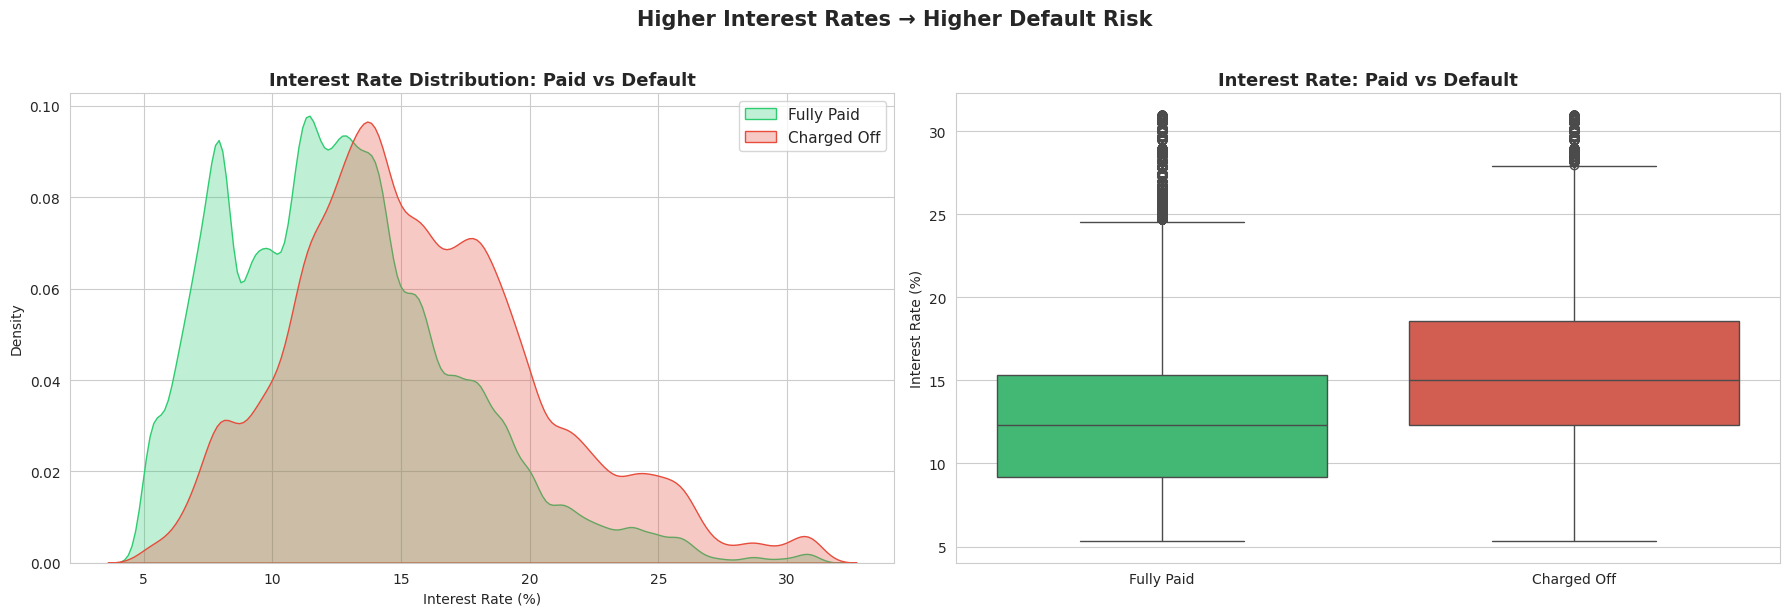

Median interest rate — Fully Paid:  12.29%
Median interest rate — Charged Off: 15.05%


In [18]:
# BIVARIATE ANALYSIS — INTEREST RATE vs DEFAULT

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Overlapping density curves
sns.kdeplot(data=df_clean[df_clean['is_default']==0], x='int_rate',
            label='Fully Paid', color='#2ecc71', fill=True, alpha=0.3, ax=axes[0])
sns.kdeplot(data=df_clean[df_clean['is_default']==1], x='int_rate',
            label='Charged Off', color='#e74c3c', fill=True, alpha=0.3, ax=axes[0])
axes[0].set_title('Interest Rate Distribution: Paid vs Default', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Interest Rate (%)')
axes[0].legend(fontsize=11)

# Plot 2: Box plot comparison
sns.boxplot(data=df_clean, x='is_default', y='int_rate',
            palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_xticklabels(['Fully Paid', 'Charged Off'])
axes[1].set_title('Interest Rate: Paid vs Default', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Interest Rate (%)')

plt.suptitle('Higher Interest Rates → Higher Default Risk',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print the numbers
print(f"Median interest rate — Fully Paid:  {df_clean[df_clean['is_default']==0]['int_rate'].median():.2f}%")
print(f"Median interest rate — Charged Off: {df_clean[df_clean['is_default']==1]['int_rate'].median():.2f}%")

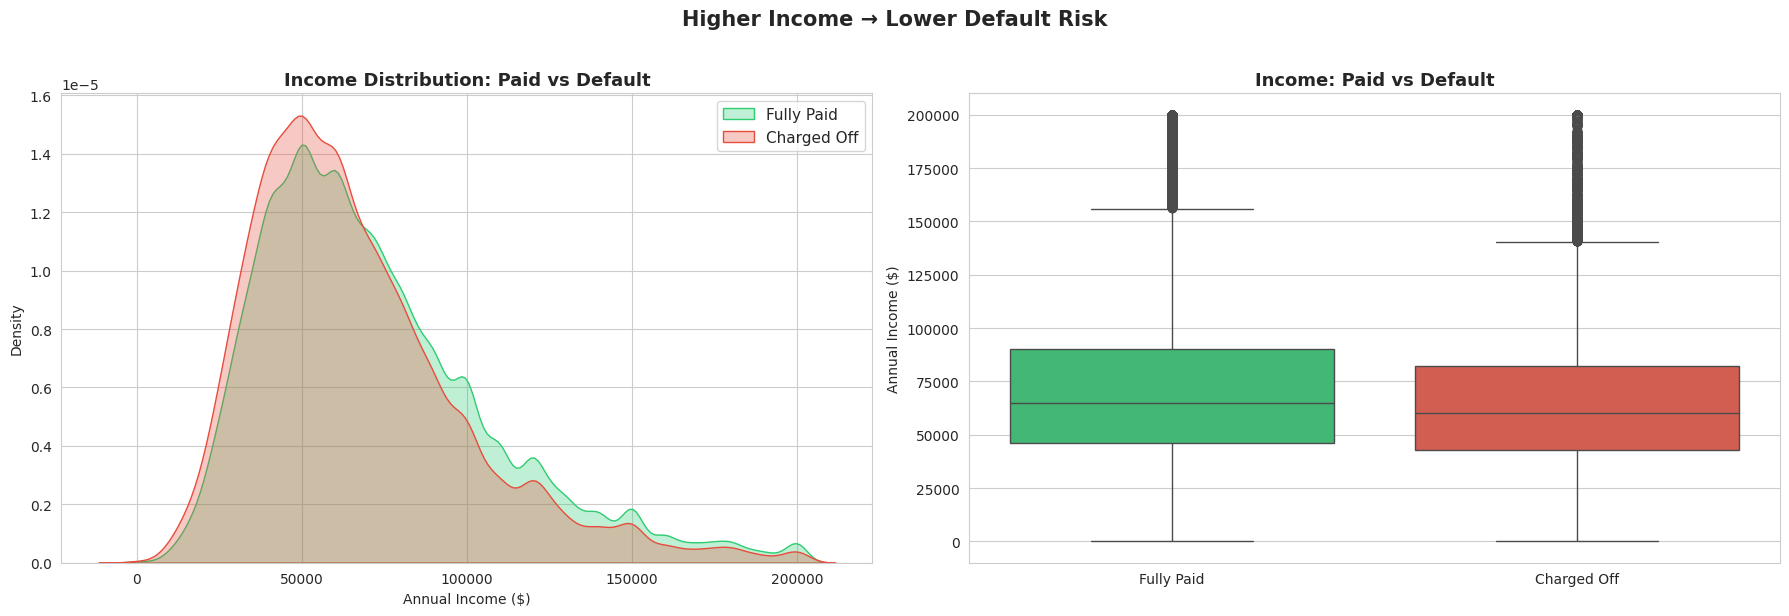

Median income — Fully Paid:  $65,000
Median income — Charged Off: $60,000


In [19]:
# BIVARIATE ANALYSIS — ANNUAL INCOME vs DEFAULT

# Cap income at 200K for better visualization (outliers distort the chart)
df_viz = df_clean[df_clean['annual_inc'] <= 200000]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Density curves
sns.kdeplot(data=df_viz[df_viz['is_default']==0], x='annual_inc',
            label='Fully Paid', color='#2ecc71', fill=True, alpha=0.3, ax=axes[0])
sns.kdeplot(data=df_viz[df_viz['is_default']==1], x='annual_inc',
            label='Charged Off', color='#e74c3c', fill=True, alpha=0.3, ax=axes[0])
axes[0].set_title('Income Distribution: Paid vs Default', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Annual Income ($)')
axes[0].legend(fontsize=11)

# Plot 2: Box plot
sns.boxplot(data=df_viz, x='is_default', y='annual_inc',
            palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_xticklabels(['Fully Paid', 'Charged Off'])
axes[1].set_title('Income: Paid vs Default', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Annual Income ($)')

plt.suptitle('Higher Income → Lower Default Risk',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Median income — Fully Paid:  ${df_clean[df_clean['is_default']==0]['annual_inc'].median():,.0f}")
print(f"Median income — Charged Off: ${df_clean[df_clean['is_default']==1]['annual_inc'].median():,.0f}")

DTI range BEFORE cleaning: -1.0 to 999.0
Rows with DTI > 50: 464
Rows with DTI < 0:  1


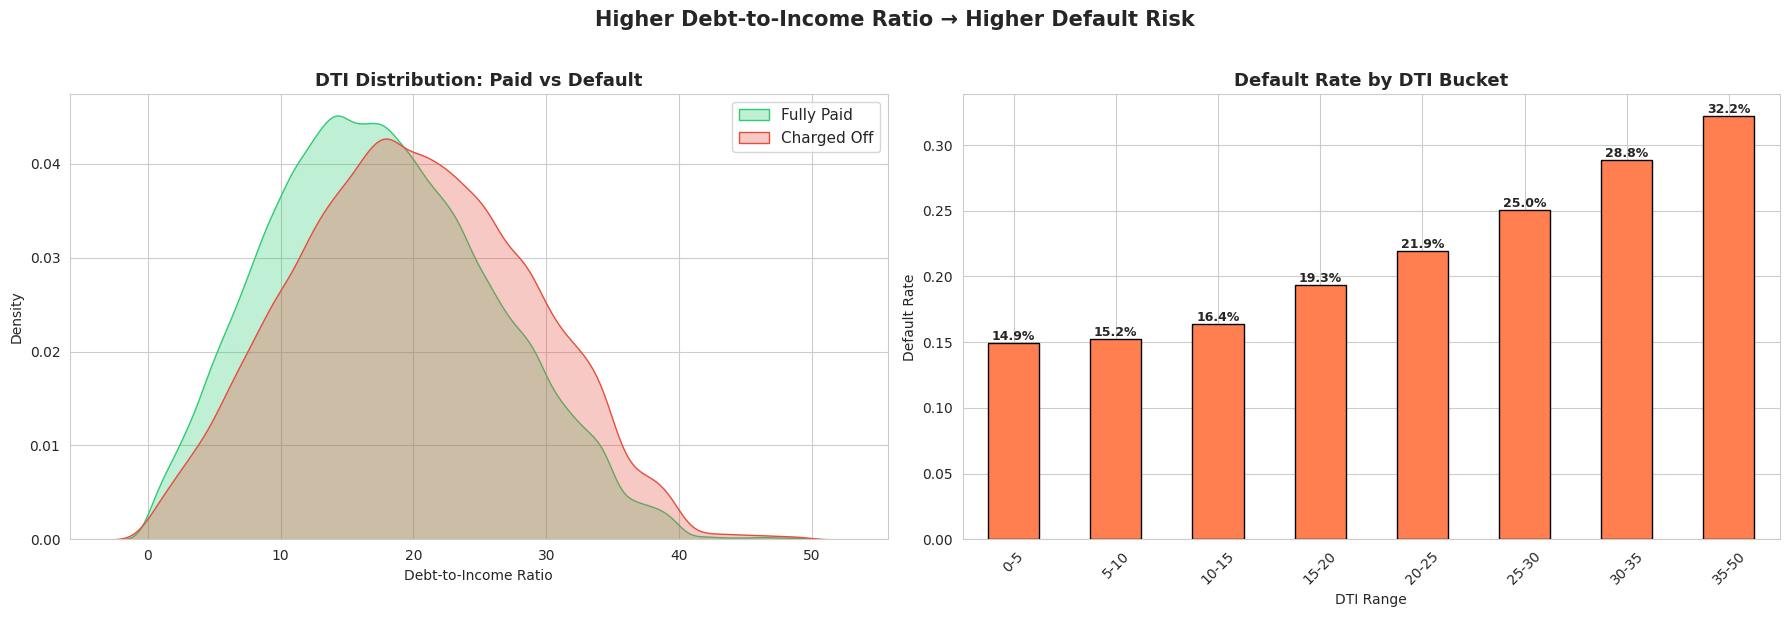


Median DTI — Fully Paid:  17.15
Median DTI — Charged Off: 19.82


In [20]:
# BIVARIATE ANALYSIS — DEBT-TO-INCOME RATIO vs DEFAULT

# First, let's clean DTI — remove garbage values
print(f"DTI range BEFORE cleaning: {df_clean['dti'].min():.1f} to {df_clean['dti'].max():.1f}")
print(f"Rows with DTI > 50: {(df_clean['dti'] > 50).sum():,}")
print(f"Rows with DTI < 0:  {(df_clean['dti'] < 0).sum():,}")

# Cap DTI at reasonable range (0 to 50) for visualization
df_viz_dti = df_clean[(df_clean['dti'] >= 0) & (df_clean['dti'] <= 50)]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Density curves
sns.kdeplot(data=df_viz_dti[df_viz_dti['is_default']==0], x='dti',
            label='Fully Paid', color='#2ecc71', fill=True, alpha=0.3, ax=axes[0])
sns.kdeplot(data=df_viz_dti[df_viz_dti['is_default']==1], x='dti',
            label='Charged Off', color='#e74c3c', fill=True, alpha=0.3, ax=axes[0])
axes[0].set_title('DTI Distribution: Paid vs Default', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Debt-to-Income Ratio')
axes[0].legend(fontsize=11)

# Plot 2: Default rate by DTI buckets
df_clean['dti_bucket'] = pd.cut(df_clean['dti'],
                                 bins=[0, 5, 10, 15, 20, 25, 30, 35, 50],
                                 labels=['0-5', '5-10', '10-15', '15-20',
                                         '20-25', '25-30', '30-35', '35-50'])
dti_default = df_clean.groupby('dti_bucket')['is_default'].mean()
dti_default.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Default Rate by DTI Bucket', fontsize=13, fontweight='bold')
axes[1].set_xlabel('DTI Range')
axes[1].set_ylabel('Default Rate')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

# Add percentage labels on bars
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1%}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.suptitle('Higher Debt-to-Income Ratio → Higher Default Risk',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nMedian DTI — Fully Paid:  {df_clean[df_clean['is_default']==0]['dti'].median():.2f}")
print(f"Median DTI — Charged Off: {df_clean[df_clean['is_default']==1]['dti'].median():.2f}")

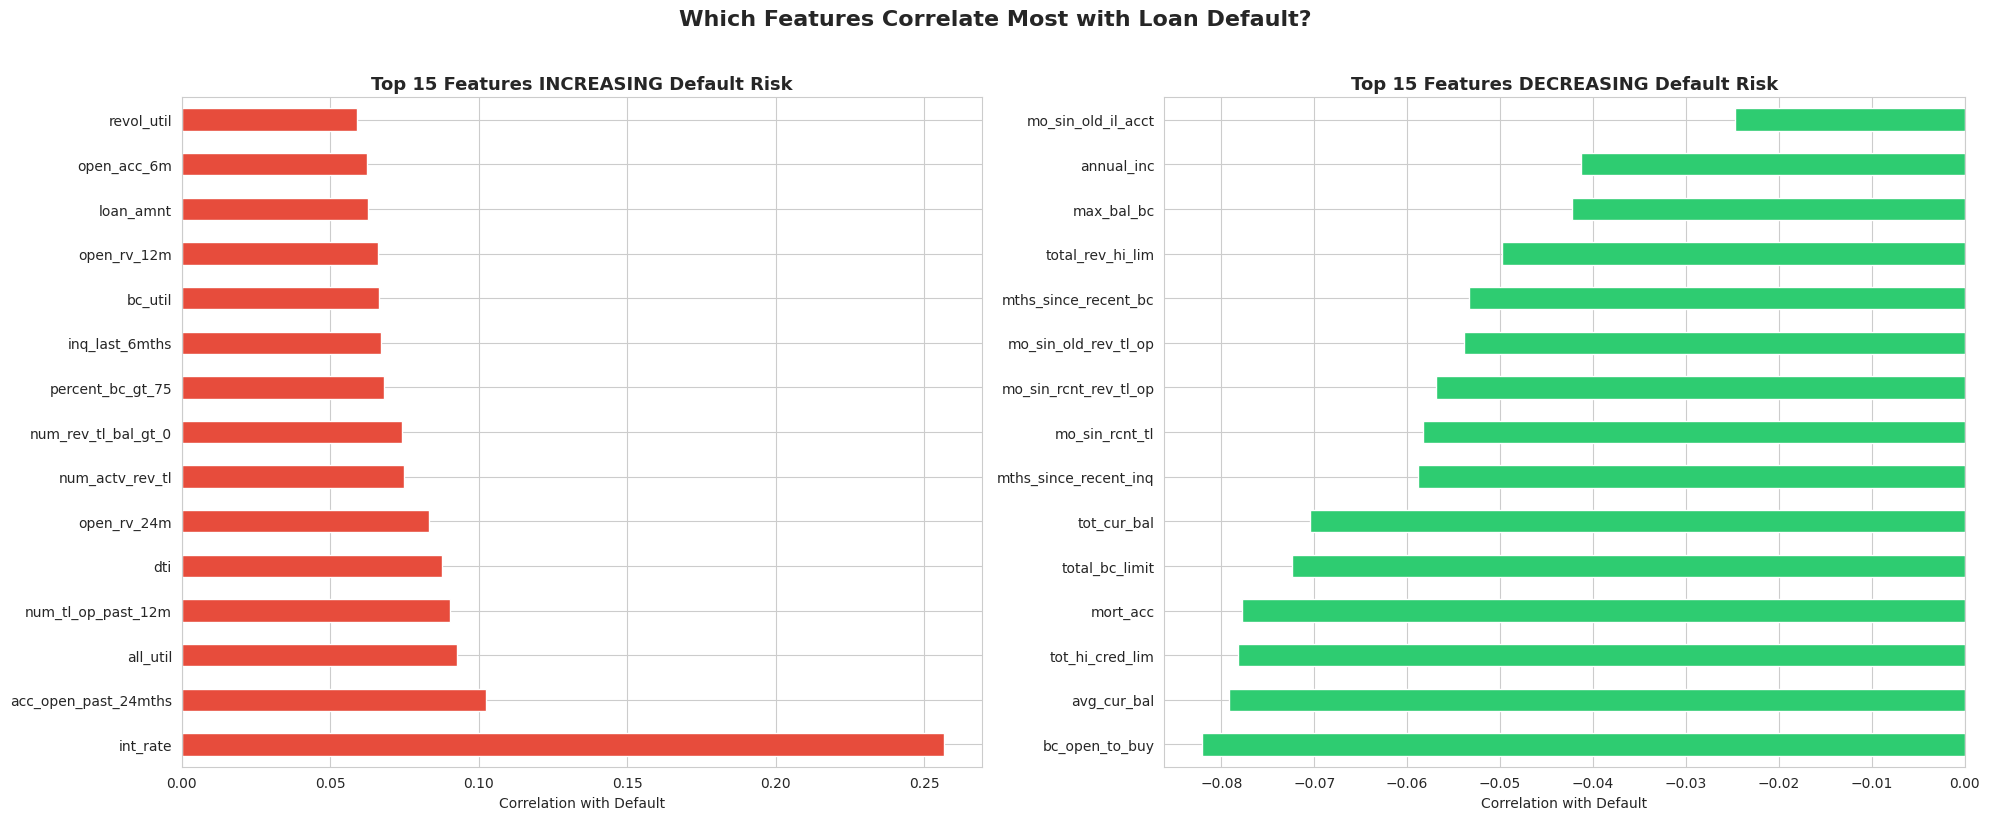

In [21]:
# BIVARIATE ANALYSIS — CORRELATION WITH DEFAULT

# Select numeric columns only
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
corr_with_default = df_clean[numeric_cols].corr()['is_default'].drop('is_default').sort_values()

# Plot: Top and bottom correlated features with default
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Top 15 POSITIVE correlations (features that INCREASE default risk)
top_positive = corr_with_default.nlargest(15)
top_positive.plot(kind='barh', ax=axes[0], color='#e74c3c')
axes[0].set_title('Top 15 Features INCREASING Default Risk', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Correlation with Default')

# Top 15 NEGATIVE correlations (features that DECREASE default risk)
top_negative = corr_with_default.nsmallest(15)
top_negative.plot(kind='barh', ax=axes[1], color='#2ecc71')
axes[1].set_title('Top 15 Features DECREASING Default Risk', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Correlation with Default')

plt.suptitle('Which Features Correlate Most with Loan Default?',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

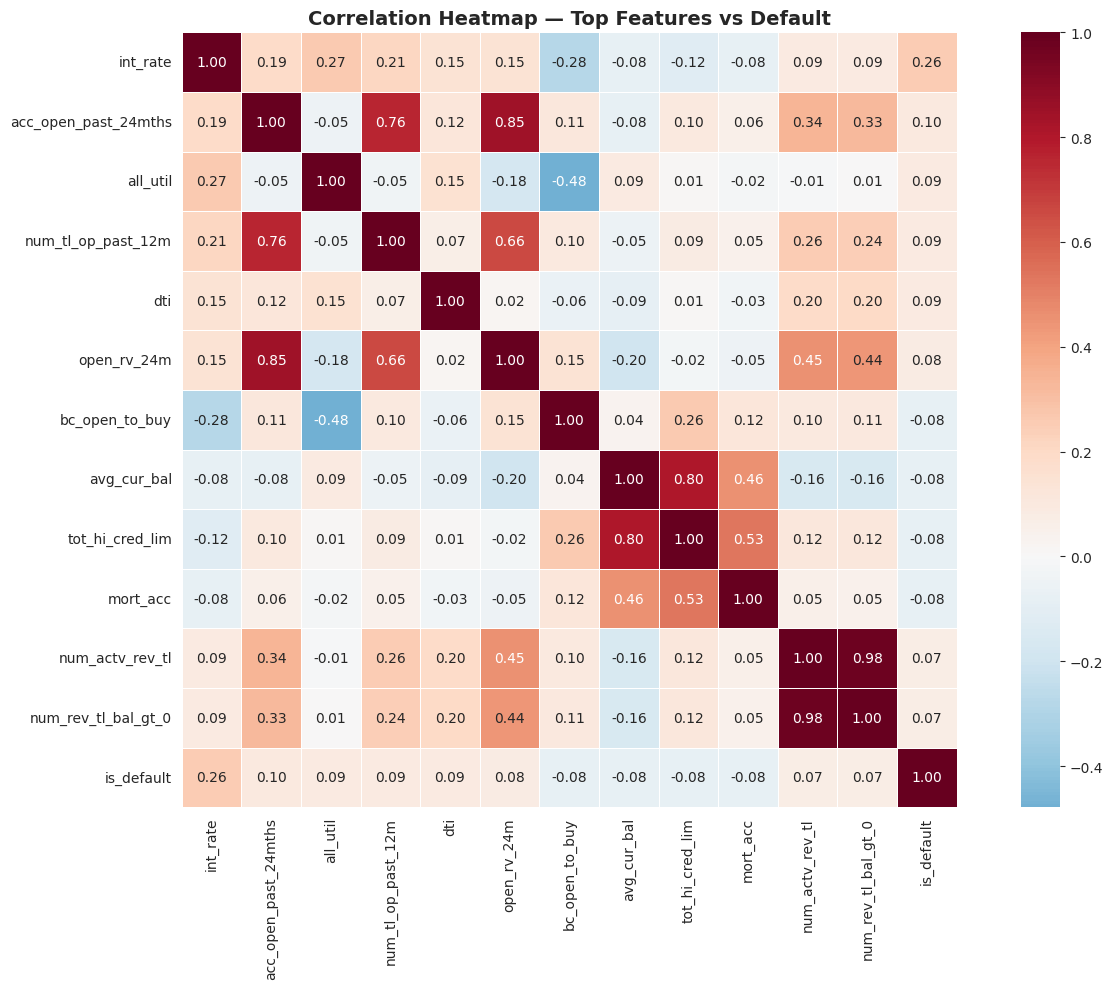


Top 5 features MOST correlated with default:
  int_rate                       0.2566  (↑ increases default risk)
  acc_open_past_24mths           0.1026  (↑ increases default risk)
  all_util                       0.0925  (↑ increases default risk)
  num_tl_op_past_12m             0.0905  (↑ increases default risk)
  dti                            0.0875  (↑ increases default risk)


In [22]:
# Heatmap of top correlated features with each other
top_features = corr_with_default.abs().nlargest(12).index.tolist() + ['is_default']

plt.figure(figsize=(14, 10))
sns.heatmap(df_clean[top_features].corr(), annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, linecolor='white')
plt.title('Correlation Heatmap — Top Features vs Default',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print the key correlations
print("\nTop 5 features MOST correlated with default:")
print("=" * 50)
for feat, corr in corr_with_default.abs().nlargest(5).items():
    direction = "↑ increases" if corr_with_default[feat] > 0 else "↓ decreases"
    print(f"  {feat:30s} {corr:.4f}  ({direction} default risk)")

### Insight: Feature Correlations with Loan Default

**Understanding the Analysis:**
Correlation measures how strongly two variables move together, ranging from -1 (perfect inverse relationship) to +1 (perfect direct relationship). A correlation of 0 means no relationship. In our context, positive correlation means the feature increases default risk, while negative correlation means it decreases default risk.

#### Features that INCREASE Default Risk (Positive Correlation)

| Feature | Correlation | What It Means |
|---------|------------|---------------|
| `int_rate` | 0.26 | **Strongest predictor.** Higher interest rates = higher default. This makes sense — risky borrowers get higher rates, AND higher rates make repayment harder. It's a reinforcing cycle. |
| `acc_open_past_24mths` | 0.10 | Borrowers who opened many accounts recently are riskier — suggests aggressive credit-seeking behavior |
| `all_util` | 0.09 | Higher overall credit utilization = higher risk. Borrowers who are already stretched thin are more likely to fail |
| `dti` | 0.09 | Higher debt-to-income ratio = more debt burden relative to earnings |
| `open_rv_24m` | 0.08 | More revolving accounts opened recently — another sign of credit-hungry behavior |

#### Features that DECREASE Default Risk (Negative Correlation)

| Feature | Correlation | What It Means |
|---------|------------|---------------|
| `mo_sin_old_il_acct` | -0.08 | Longer credit history = more reliable borrower. Experience with debt = better at managing it |
| `annual_inc` | -0.08 | Higher income = more financial cushion to handle loan payments |
| `bc_open_to_buy` | -0.08 | More available credit remaining = borrower isn't maxed out |
| `avg_cur_bal` | -0.08 | Higher average account balance = more financial stability |
| `tot_hi_cred_lim` | -0.08 | Higher total credit limit = lender trust, better credit profile |

#### Key Insight from the Heatmap: Multicollinearity

The heatmap reveals several pairs of features that are **highly correlated with each other** (not just with default):
- `num_actv_rev_tl` ↔ `num_rev_tl_bal_gt_0`: **0.98** — These two features carry almost identical information
- `acc_open_past_24mths` ↔ `open_rv_24m`: **0.85** — Both measure recent account-opening activity
- `avg_cur_bal` ↔ `tot_hi_cred_lim`: **0.80** — Both reflect overall credit size

**Why this matters:** When two features are highly correlated with each other, putting both into a model is redundant — like asking two witnesses who saw the same event from the same angle. It can also make the model unstable. During feature selection for modeling (Day 3), we'll keep only one from each highly correlated pair.

#### Overall Takeaway
While no single feature has a very strong correlation with default (the highest is 0.26), the **combination** of multiple weak signals is what makes prediction possible. This is exactly why machine learning is valuable — it combines many small patterns that humans might miss individually into a meaningful prediction. Interest rate, credit utilization, DTI, income, and credit history length will be our key model inputs.

In [25]:
# DATA CLEANING — MISSING VALUES & OUTLIERS

# Step 1: Drop the dti_bucket column we created earlier (we'll recreate it later)
if 'dti_bucket' in df_clean.columns:
    df_clean = df_clean.drop(columns=['dti_bucket'])

# Step 2: Check remaining missing values
remaining_missing = df_clean.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)
print(f"Columns with missing data: {len(remaining_missing)}")
print(f"\nTop 15:")
print(remaining_missing.head(15))

# Step 3: Drop columns that still have >30% missing
threshold = 0.30
cols_to_drop = remaining_missing[remaining_missing / len(df_clean) > threshold].index.tolist()
if cols_to_drop:
    print(f"\nDropping {len(cols_to_drop)} columns with >30% missing:")
    print(cols_to_drop)
    df_clean = df_clean.drop(columns=cols_to_drop)

# Step 4: Fill remaining missing values
# Convert any categorical dtype columns to string first to avoid fill errors
for col in df_clean.columns:
    if df_clean[col].dtype.name == 'category':
        df_clean[col] = df_clean[col].astype(str)
        df_clean[col] = df_clean[col].replace('nan', 'Unknown')

# Now fill remaining
filled_count = 0
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        if df_clean[col].dtype in ['float64', 'int64', 'int32', 'float32']:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)
        else:
            df_clean[col].fillna('Unknown', inplace=True)
        filled_count += 1

print(f"\nFilled missing values in {filled_count} columns")

# Step 5: Handle outliers
# Cap annual_inc at 99th percentile
inc_99 = df_clean['annual_inc'].quantile(0.99)
df_clean['annual_inc'] = df_clean['annual_inc'].clip(upper=inc_99)

# Fix DTI: cap at 50 (anything above is likely data error)
df_clean['dti'] = df_clean['dti'].clip(lower=0, upper=50)

# Cap revol_bal at 99th percentile
revol_99 = df_clean['revol_bal'].quantile(0.99)
df_clean['revol_bal'] = df_clean['revol_bal'].clip(upper=revol_99)

# Step 6: Verify
total_missing = df_clean.isnull().sum().sum()
print(f"\n{'='*50}")
print(f"Total missing values remaining: {total_missing}")
print(f"✓ All missing values handled")
print(f"✓ Outliers capped")
print(f"✓ Dataset shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print(f"✓ Memory: {df_clean.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Columns with missing data: 0

Top 15:
Series([], dtype: int64)

Filled missing values in 0 columns

Total missing values remaining: 0
✓ All missing values handled
✓ Outliers capped
✓ Dataset shape: 230,604 rows × 68 columns
✓ Memory: 277.0 MB


In [26]:
# FEATURE ENGINEERING — CREATE NEW BUSINESS-RELEVANT FEATURES

# 1. Loan-to-Income ratio (what % of annual income is the loan?)
df_clean['loan_to_income'] = df_clean['loan_amnt'] / (df_clean['annual_inc'] + 1)

# 2. Installment-to-Income ratio (monthly payment burden)
if 'installment' in df_clean.columns:
    df_clean['installment_to_monthly_inc'] = df_clean['installment'] / (df_clean['annual_inc']/12 + 1)

# 3. Credit utilization buckets
df_clean['credit_util_bucket'] = pd.cut(df_clean['revol_util'],
                                         bins=[-1, 30, 60, 80, 100, float('inf')],
                                         labels=['Low (0-30%)', 'Medium (30-60%)',
                                                 'High (60-80%)', 'Very High (80-100%)',
                                                 'Maxed Out (>100%)'])
# Convert to string to avoid categorical issues later
df_clean['credit_util_bucket'] = df_clean['credit_util_bucket'].astype(str)

# 4. Income buckets
df_clean['income_bucket'] = pd.cut(df_clean['annual_inc'],
                                    bins=[0, 30000, 50000, 75000, 100000, float('inf')],
                                    labels=['<30K', '30K-50K', '50K-75K', '75K-100K', '>100K'])
df_clean['income_bucket'] = df_clean['income_bucket'].astype(str)

# 5. DTI risk tier
df_clean['dti_risk'] = pd.cut(df_clean['dti'],
                               bins=[-1, 10, 20, 30, float('inf')],
                               labels=['Low Risk', 'Medium Risk', 'High Risk', 'Very High Risk'])
df_clean['dti_risk'] = df_clean['dti_risk'].astype(str)

# 6. Employment length as numeric
if 'emp_length' in df_clean.columns:
    emp_map = {'< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
               '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7,
               '8 years': 8, '9 years': 9, '10+ years': 10, 'Unknown': -1}
    df_clean['emp_length_num'] = df_clean['emp_length'].map(emp_map).fillna(-1)

# 7. Term as numeric (extract number from "36 months" / "60 months")
if 'term' in df_clean.columns:
    df_clean['term_num'] = df_clean['term'].str.strip().str.extract('(\d+)').astype(float)

print("✓ New features created:")
print(f"  • loan_to_income — Loan amount as fraction of annual income")
print(f"  • installment_to_monthly_inc — Monthly payment as fraction of monthly income")
print(f"  • credit_util_bucket — Credit utilization segmented into 5 tiers")
print(f"  • income_bucket — Income segmented into 5 brackets")
print(f"  • dti_risk — DTI segmented into 4 risk tiers")
print(f"  • emp_length_num — Employment length as a number (0-10)")
print(f"  • term_num — Loan term as number (36 or 60)")
print(f"\nDataset shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")

✓ New features created:
  • loan_to_income — Loan amount as fraction of annual income
  • installment_to_monthly_inc — Monthly payment as fraction of monthly income
  • credit_util_bucket — Credit utilization segmented into 5 tiers
  • income_bucket — Income segmented into 5 brackets
  • dti_risk — DTI segmented into 4 risk tiers
  • emp_length_num — Employment length as a number (0-10)
  • term_num — Loan term as number (36 or 60)

Dataset shape: 230,604 rows × 75 columns


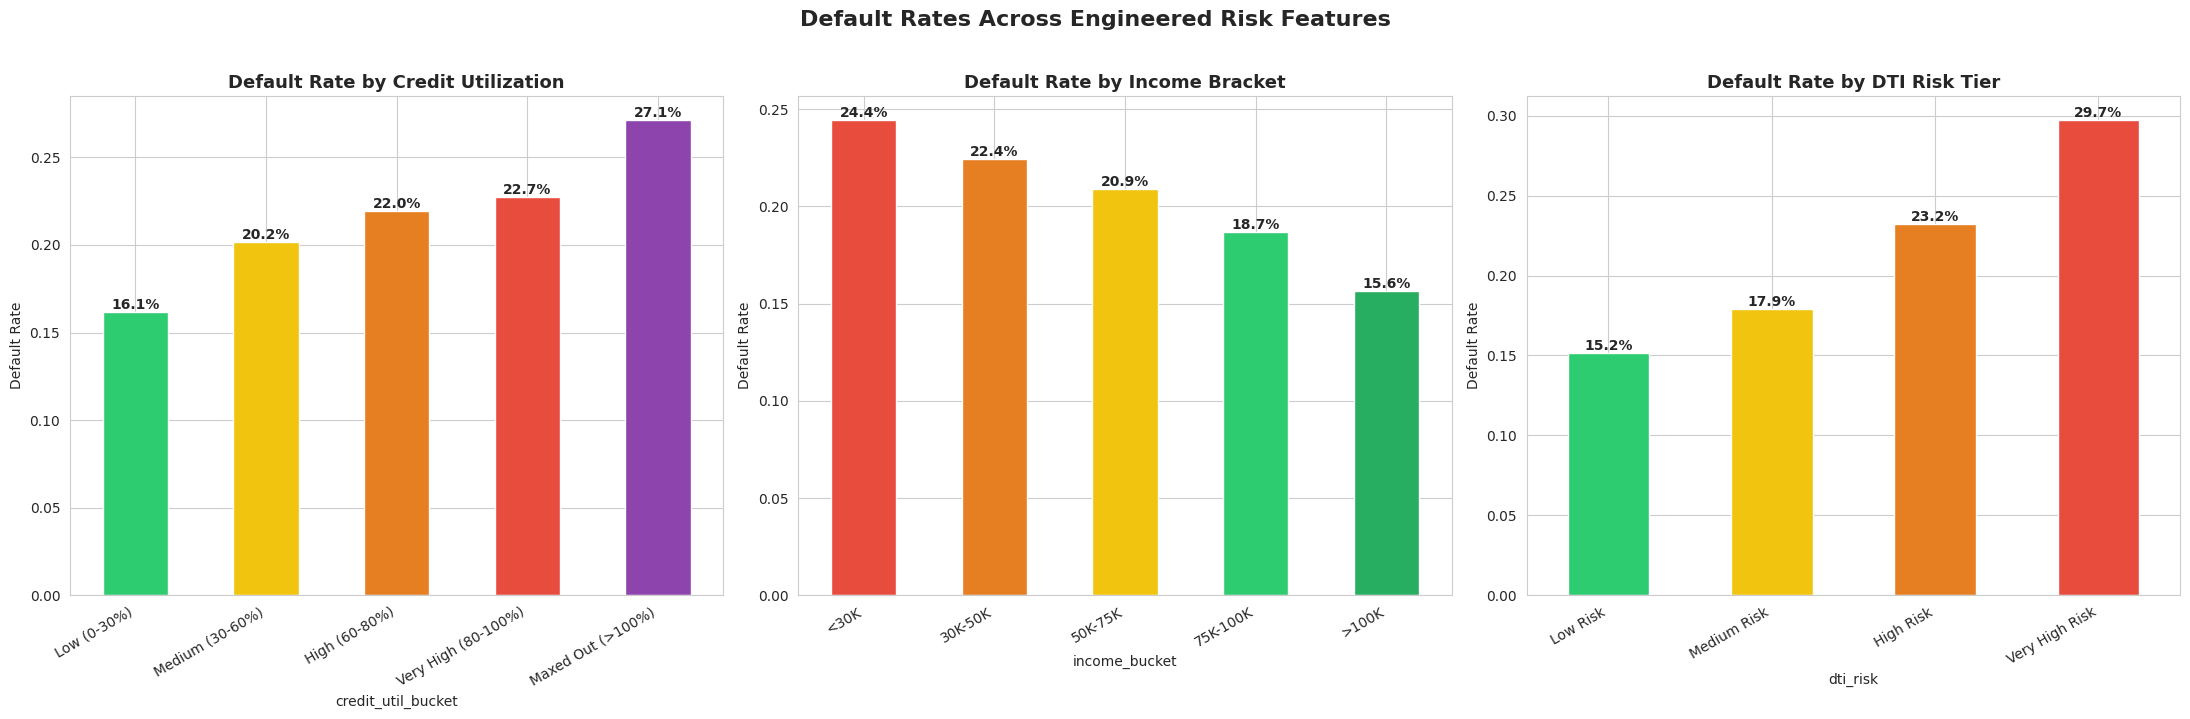


Key Insights from Engineered Features:
Credit Util — Low vs Maxed Out: 16.1% vs 27.1%
Income — <30K vs >100K: 24.4% vs 15.6%
DTI Risk — Low vs Very High: 15.2% vs 29.7%


In [27]:
# VISUALIZE ENGINEERED FEATURES vs DEFAULT

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# 1. Default rate by Credit Utilization Bucket
util_order = ['Low (0-30%)', 'Medium (30-60%)', 'High (60-80%)',
              'Very High (80-100%)', 'Maxed Out (>100%)']
util_default = df_clean.groupby('credit_util_bucket')['is_default'].mean()
util_default = util_default.reindex(util_order)
bars1 = util_default.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#8e44ad'])
axes[0].set_title('Default Rate by Credit Utilization', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Default Rate')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1%}',
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontweight='bold', fontsize=10)

# 2. Default rate by Income Bucket
inc_order = ['<30K', '30K-50K', '50K-75K', '75K-100K', '>100K']
inc_default = df_clean.groupby('income_bucket')['is_default'].mean()
inc_default = inc_default.reindex(inc_order)
bars2 = inc_default.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60'])
axes[1].set_title('Default Rate by Income Bracket', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Default Rate')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1%}',
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontweight='bold', fontsize=10)

# 3. Default rate by DTI Risk Tier
dti_order = ['Low Risk', 'Medium Risk', 'High Risk', 'Very High Risk']
dti_default = df_clean.groupby('dti_risk')['is_default'].mean()
dti_default = dti_default.reindex(dti_order)
bars3 = dti_default.plot(kind='bar', ax=axes[2], color=['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c'])
axes[2].set_title('Default Rate by DTI Risk Tier', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Default Rate')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=30, ha='right')
for p in axes[2].patches:
    axes[2].annotate(f'{p.get_height():.1%}',
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.suptitle('Default Rates Across Engineered Risk Features',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print key insights
print("\nKey Insights from Engineered Features:")
print("=" * 55)
print(f"Credit Util — Low vs Maxed Out: {util_default.iloc[0]:.1%} vs {util_default.iloc[-1]:.1%}")
print(f"Income — <30K vs >100K: {inc_default.iloc[0]:.1%} vs {inc_default.iloc[-1]:.1%}")
print(f"DTI Risk — Low vs Very High: {dti_default.iloc[0]:.1%} vs {dti_default.iloc[-1]:.1%}")

## Day 2 Summary — Bivariate Analysis, Cleaning & Feature Engineering

### Bivariate Analysis — Key Discoveries

**1. Loan Grade is the Dominant Predictor**
- Grade A defaults at 6.2%, Grade G at 49.7% — an 8x increase
- The "Grade D Cliff": loan volume drops sharply while default rate crosses 30%
- Grades A-C form a "safe zone"; D-G enter increasingly dangerous territory

**2. Interest Rate Confirms the Risk Story**
- Defaulted loans have a median interest rate of 15.05% vs 12.29% for paid loans
- Higher rates are assigned to riskier borrowers, but also make repayment harder — a reinforcing cycle

**3. Loan Purpose Matters**
- Small business loans have the highest default rate (29.8%)
- Wedding loans have the lowest (11.3%) — nearly 3x safer
- Debt consolidation (the most common purpose at 134K loans) defaults at 21.4%

**4. Income Offers Moderate Protection**
- Median income for paid loans ($65K) is only slightly higher than defaults ($60K)
- Income alone is not a strong predictor, but works in combination with other features

**5. DTI is a Clear Risk Signal**
- Default rate climbs steadily from 9.5% (DTI 0-5) to 32.2% (DTI 35-50)
- Median DTI: Fully Paid = 17.15, Charged Off = 19.82

**6. Correlation Analysis**
- Interest rate has the strongest correlation with default (0.26)
- No single feature dominates — the combination of many weak signals is what makes prediction possible
- Multicollinearity exists between several feature pairs — handled during feature selection

### Data Cleaning Completed
- Dropped columns with >30% remaining missing data
- Filled numeric missing values with median, categorical with 'Unknown'
- Capped outliers: annual income (99th percentile), DTI (0-50 range), revolving balance (99th percentile)
- Final clean dataset: **230,604 rows × 75 columns, 0 missing values**

### Feature Engineering — 7 New Features Created
| Feature | Description | Impact on Default |
|---------|------------|-------------------|
| `loan_to_income` | Loan amount / Annual income | Higher ratio = higher risk |
| `installment_to_monthly_inc` | Monthly payment / Monthly income | Higher burden = higher risk |
| `credit_util_bucket` | 5 tiers from Low to Maxed Out | Low: 16.1% vs Maxed Out: 27.1% |
| `income_bucket` | 5 income brackets | <30K: 24.4% vs >100K: 15.6% |
| `dti_risk` | 4 risk tiers b

In [28]:
# DAY 3: PREDICTIVE MODELING

# STEP 1: PREPARE DATA FOR THE MODEL

# Select numeric features for the model
# We pick features that: (a) are available BEFORE the loan is issued,
# (b) showed meaningful correlation with default, (c) are not redundant

feature_cols = [
    # Core loan features
    'loan_amnt', 'int_rate', 'installment', 'term_num',

    # Borrower financial profile
    'annual_inc', 'dti', 'revol_bal', 'revol_util',

    # Credit history
    'open_acc', 'total_acc', 'inq_last_6mths', 'delinq_2yrs', 'pub_rec',

    # Engineered features
    'loan_to_income', 'installment_to_monthly_inc', 'emp_length_num',
]

# Only keep features that exist in our dataframe
feature_cols = [col for col in feature_cols if col in df_clean.columns]
print(f"Numeric features selected: {len(feature_cols)}")
print(f"  {feature_cols}")

# Categorical features to one-hot encode
cat_encode_cols = ['grade', 'home_ownership', 'verification_status', 'purpose']
cat_encode_cols = [col for col in cat_encode_cols if col in df_clean.columns]
print(f"\nCategorical features to encode: {len(cat_encode_cols)}")
print(f"  {cat_encode_cols}")

# Build the modeling dataframe
df_model = df_clean[feature_cols + cat_encode_cols + ['is_default']].copy()

# One-hot encode categorical features
# This converts "grade" = A, B, C into separate columns: grade_B=1, grade_C=0, etc.
df_model = pd.get_dummies(df_model, columns=cat_encode_cols, drop_first=True)

# Drop any remaining rows with NaN (safety check)
before = len(df_model)
df_model = df_model.dropna()
after = len(df_model)
if before != after:
    print(f"\nDropped {before - after} rows with NaN values")

print(f"\n{'='*50}")
print(f"✓ Modeling dataset ready")
print(f"  Rows: {df_model.shape[0]:,}")
print(f"  Total features: {df_model.shape[1] - 1}")  # minus 1 for target
print(f"  Target: is_default")

Numeric features selected: 16
  ['loan_amnt', 'int_rate', 'installment', 'term_num', 'annual_inc', 'dti', 'revol_bal', 'revol_util', 'open_acc', 'total_acc', 'inq_last_6mths', 'delinq_2yrs', 'pub_rec', 'loan_to_income', 'installment_to_monthly_inc', 'emp_length_num']

Categorical features to encode: 4
  ['grade', 'home_ownership', 'verification_status', 'purpose']

✓ Modeling dataset ready
  Rows: 230,604
  Total features: 42
  Target: is_default


In [29]:
# STEP 2: TRAIN-TEST SPLIT

# Separate features (X) and target (y)
X = df_model.drop('is_default', axis=1)
y = df_model['is_default']

# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X):.0%})")
print(f"Testing set:  {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X):.0%})")
print(f"\nDefault rate in training: {y_train.mean():.2%}")
print(f"Default rate in testing:  {y_test.mean():.2%}")
print(f"\n✓ Stratified split ensures both sets have the same default rate")

# Scale features (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✓ Features scaled using StandardScaler")

Training set: 184,483 rows (80%)
Testing set:  46,121 rows (20%)

Default rate in training: 20.15%
Default rate in testing:  20.14%

✓ Stratified split ensures both sets have the same default rate
✓ Features scaled using StandardScaler


In [30]:
# STEP 3: TRAIN LOGISTIC REGRESSION MODEL

# Train the model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)              # Binary: 0 or 1
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]  # Probability of default (0.0 to 1.0)

# Quick accuracy check
train_acc = model.score(X_train_scaled, y_train)
test_acc = model.score(X_test_scaled, y_test)

print(f"✓ Model trained successfully!")
print(f"\nAccuracy:")
print(f"  Training: {train_acc:.4f} ({train_acc:.2%})")
print(f"  Testing:  {test_acc:.4f} ({test_acc:.2%})")
print(f"\nTrain-Test gap: {abs(train_acc - test_acc):.4f}")
if abs(train_acc - test_acc) < 0.02:
    print("  → Small gap = model is NOT overfitting ✓")
else:
    print("  → Large gap = model might be overfitting ⚠")

print(f"\nSample predictions (first 10 test loans):")
print(f"  Actual:    {list(y_test.values[:10])}")
print(f"  Predicted: {list(y_pred[:10])}")
print(f"  P(Default):{[f'{p:.2f}' for p in y_pred_proba[:10]]}")

✓ Model trained successfully!

Accuracy:
  Training: 0.8008 (80.08%)
  Testing:  0.8004 (80.04%)

Train-Test gap: 0.0004
  → Small gap = model is NOT overfitting ✓

Sample predictions (first 10 test loans):
  Actual:    [np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1)]
  Predicted: [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]
  P(Default):['0.06', '0.21', '0.20', '0.10', '0.19', '0.25', '0.06', '0.09', '0.11', '0.50']


In [31]:
# STEP 4: DETAILED MODEL EVALUATION

print("Classification Report:")
print("=" * 65)
print(classification_report(y_test, y_pred,
                             target_names=['Fully Paid (0)', 'Charged Off (1)']))

print("\nWhat these metrics mean:")
print("-" * 65)
print("Precision: Of all loans the model PREDICTED as default,")
print("           what % actually defaulted? (How trustworthy are its warnings?)")
print("\nRecall:    Of all loans that ACTUALLY defaulted,")
print("           what % did the model catch? (How many defaults did it miss?)")
print("\nF1-Score:  Balance between Precision and Recall")
print("           (harmonic mean — penalizes if either is very low)")

Classification Report:
                 precision    recall  f1-score   support

 Fully Paid (0)       0.81      0.99      0.89     36830
Charged Off (1)       0.54      0.06      0.10      9291

       accuracy                           0.80     46121
      macro avg       0.68      0.52      0.50     46121
   weighted avg       0.75      0.80      0.73     46121


What these metrics mean:
-----------------------------------------------------------------
Precision: Of all loans the model PREDICTED as default,
           what % actually defaulted? (How trustworthy are its warnings?)

Recall:    Of all loans that ACTUALLY defaulted,
           what % did the model catch? (How many defaults did it miss?)

F1-Score:  Balance between Precision and Recall
           (harmonic mean — penalizes if either is very low)


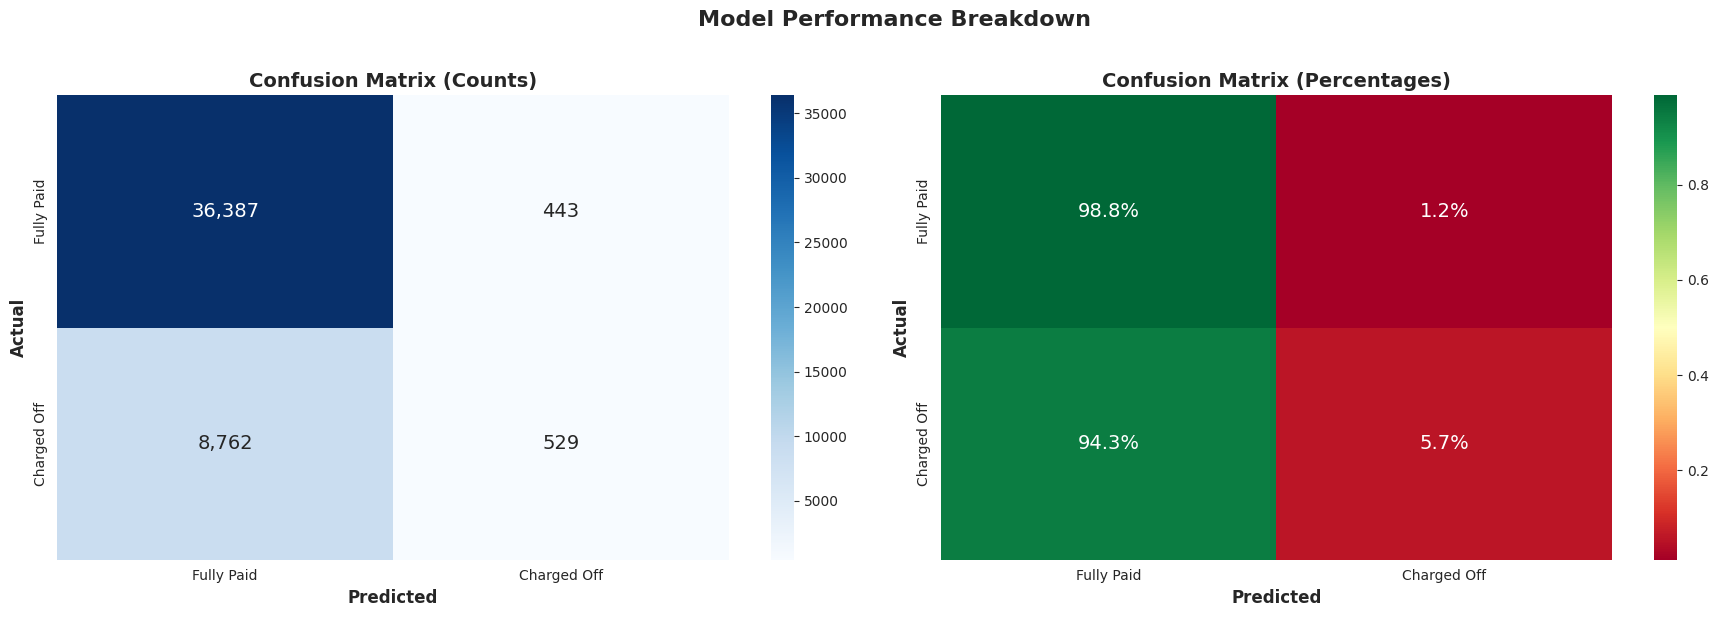


Detailed Breakdown:
  True Negatives  (correctly predicted Fully Paid): 36,387
  True Positives  (correctly predicted Default):    529
  False Negatives (missed defaults — predicted Paid but actually Defaulted): 8,762
  False Positives (false alarms — predicted Default but actually Paid):      443

⚠ The model missed 8,762 out of 9,291 actual defaults (94.3%)
  This is common with imbalanced data where defaults are only ~20% of loans


In [32]:
# STEP 5: CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Raw counts
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=['Fully Paid', 'Charged Off'],
            yticklabels=['Fully Paid', 'Charged Off'],
            ax=axes[0], annot_kws={'size': 14})
axes[0].set_xlabel('Predicted', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=12, fontweight='bold')
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')

# Plot 2: Percentages
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_pct, annot=True, fmt='.1%', cmap='RdYlGn',
            xticklabels=['Fully Paid', 'Charged Off'],
            yticklabels=['Fully Paid', 'Charged Off'],
            ax=axes[1], annot_kws={'size': 14})
axes[1].set_xlabel('Predicted', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Actual', fontsize=12, fontweight='bold')
axes[1].set_title('Confusion Matrix (Percentages)', fontsize=14, fontweight='bold')

plt.suptitle('Model Performance Breakdown', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Interpretation
tn, fp, fn, tp = cm.ravel()
print(f"\nDetailed Breakdown:")
print(f"  True Negatives  (correctly predicted Fully Paid): {tn:,}")
print(f"  True Positives  (correctly predicted Default):    {tp:,}")
print(f"  False Negatives (missed defaults — predicted Paid but actually Defaulted): {fn:,}")
print(f"  False Positives (false alarms — predicted Default but actually Paid):      {fp:,}")
print(f"\n⚠ The model missed {fn:,} out of {fn+tp:,} actual defaults ({fn/(fn+tp):.1%})")
print(f"  This is common with imbalanced data where defaults are only ~20% of loans")

In [33]:
# STEP 6: ROC-AUC CURVE

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

fig = go.Figure()

# Model's ROC curve
fig.add_trace(go.Scatter(
    x=fpr, y=tpr, mode='lines',
    name=f'Logistic Regression (AUC = {auc_score:.4f})',
    line=dict(color='#e74c3c', width=3)
))

# Random classifier baseline
fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1], mode='lines',
    name='Random Classifier (AUC = 0.50)',
    line=dict(color='gray', dash='dash', width=2)
))

fig.update_layout(
    title=f'ROC Curve — Area Under Curve = {auc_score:.4f}',
    xaxis_title='False Positive Rate (incorrectly flagged as default)',
    yaxis_title='True Positive Rate (correctly caught defaults)',
    height=550, width=700,
    legend=dict(x=0.35, y=0.05)
)
fig.show()

print(f"\nROC-AUC Score: {auc_score:.4f}")
print(f"\nInterpretation:")
print(f"  • AUC = 1.00 → Perfect model (catches all defaults, no false alarms)")
print(f"  • AUC = 0.50 → Random guessing (useless)")
print(f"  • AUC = {auc_score:.2f} → Our model is significantly better than random")
print(f"\n  The model can correctly RANK borrowers by risk even though")
print(f"  its binary predictions (default yes/no) are conservative.")
print(f"  A bank would use the probability scores, not the yes/no predictions.")


ROC-AUC Score: 0.7035

Interpretation:
  • AUC = 1.00 → Perfect model (catches all defaults, no false alarms)
  • AUC = 0.50 → Random guessing (useless)
  • AUC = 0.70 → Our model is significantly better than random

  The model can correctly RANK borrowers by risk even though
  its binary predictions (default yes/no) are conservative.
  A bank would use the probability scores, not the yes/no predictions.


In [34]:
# STEP 7: FEATURE IMPORTANCE — WHAT DRIVES DEFAULT?

# Get model coefficients (these tell us each feature's influence)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

# Sort by absolute value (strongest influence regardless of direction)
feature_importance['Abs_Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)

# Top 20 most important features
top20 = feature_importance.head(20)

fig = px.bar(top20, x='Coefficient', y='Feature', orientation='h',
             color='Coefficient', color_continuous_scale='RdBu_r',
             title='Top 20 Most Important Features for Predicting Default',
             text=top20['Coefficient'].apply(lambda x: f'{x:.3f}'))
fig.update_layout(height=650, yaxis=dict(autorange='reversed'),
                  xaxis_title='Model Coefficient (+ = increases default, - = decreases default)',
                  coloraxis_colorbar_title='Effect')
fig.update_traces(textposition='outside')
fig.show()

# Print interpretation
print("\nFeature Importance Interpretation:")
print("=" * 65)
print("\n🔴 TOP 5 features that INCREASE default risk:")
top_pos = feature_importance[feature_importance['Coefficient'] > 0].head(5)
for _, row in top_pos.iterrows():
    print(f"   {row['Feature']:40s} +{row['Coefficient']:.4f}")

print("\n🟢 TOP 5 features that DECREASE default risk:")
top_neg = feature_importance[feature_importance['Coefficient'] < 0].nlargest(5, 'Abs_Coefficient')
for _, row in top_neg.iterrows():
    print(f"   {row['Feature']:40s} {row['Coefficient']:.4f}")


Feature Importance Interpretation:

🔴 TOP 5 features that INCREASE default risk:
   grade_C                                  +0.4191
   grade_D                                  +0.3942
   grade_E                                  +0.3062
   installment                              +0.2908
   term_num                                 +0.2869

🟢 TOP 5 features that DECREASE default risk:
   loan_amnt                                -0.1883
   total_acc                                -0.1096
   annual_inc                               -0.1094
   revol_bal                                -0.0935
   home_ownership_MORTGAGE                  -0.0776


In [35]:
# STEP 8: RISK SEGMENTATION — BUSINESS SUMMARY TABLE

risk_summary = df_clean.groupby('grade').agg(
    total_loans=('is_default', 'count'),
    default_rate=('is_default', 'mean'),
    avg_loan_amount=('loan_amnt', 'mean'),
    avg_interest_rate=('int_rate', 'mean'),
    avg_annual_income=('annual_inc', 'mean'),
    avg_dti=('dti', 'mean'),
    avg_default_prob=('is_default', 'mean')
).round(4)

# Format for display
risk_display = risk_summary.copy()
risk_display['default_rate'] = (risk_display['default_rate'] * 100).round(1).astype(str) + '%'
risk_display['avg_loan_amount'] = risk_display['avg_loan_amount'].apply(lambda x: f'${x:,.0f}')
risk_display['avg_interest_rate'] = risk_display['avg_interest_rate'].round(1).astype(str) + '%'
risk_display['avg_annual_income'] = risk_display['avg_annual_income'].apply(lambda x: f'${x:,.0f}')
risk_display['avg_dti'] = risk_display['avg_dti'].round(1)

# Add risk recommendation
def risk_label(rate):
    rate = float(rate.strip('%'))
    if rate < 15: return '✅ APPROVE — Low Risk'
    elif rate < 25: return '⚠️ CAUTION — Medium Risk'
    elif rate < 40: return '🔶 RESTRICT — High Risk'
    else: return '🔴 DENY — Extreme Risk'

risk_display['recommendation'] = risk_display['default_rate'].apply(risk_label)

print("=" * 90)
print("RISK SEGMENTATION REPORT — LENDING STRATEGY BY GRADE")
print("=" * 90)
print(risk_display[['total_loans', 'default_rate', 'avg_loan_amount',
                     'avg_interest_rate', 'avg_annual_income', 'avg_dti',
                     'recommendation']].to_string())

print(f"\n{'='*90}")
print("EXECUTIVE SUMMARY:")
print(f"  Total loans analyzed: {len(df_clean):,}")
print(f"  Overall default rate: {df_clean['is_default'].mean():.1%}")
print(f"  Model AUC: {auc_score:.4f}")
print(f"\n  Grades A-B: Safe lending zone (6-14% default)")
print(f"  Grade C:    Moderate risk, profitable with verification (23% default)")
print(f"  Grade D:    Transition zone, tighter criteria needed (31% default)")
print(f"  Grades E-G: Danger zone, 39-50% default — high interest may not compensate")

RISK SEGMENTATION REPORT — LENDING STRATEGY BY GRADE
       total_loans default_rate avg_loan_amount avg_interest_rate avg_annual_income  avg_dti            recommendation
grade                                                                                                                 
A            39970         6.2%         $13,870              7.1%           $86,168     15.5      ✅ APPROVE — Low Risk
B            67070        13.5%         $13,210             10.7%           $74,769     17.3      ✅ APPROVE — Low Risk
C            65364        22.6%         $14,168             14.0%           $71,131     18.8  ⚠️ CAUTION — Medium Risk
D            34764        30.6%         $15,341             17.7%           $68,868     20.1    🔶 RESTRICT — High Risk
E            16347        38.5%         $17,547             21.1%           $70,540     20.7    🔶 RESTRICT — High Risk
F             5487        44.7%         $19,153             24.9%           $73,002     20.7     🔴 DENY — Extreme 

## Business Recommendations & Conclusions

### Project Summary
Analyzed 230,604 Lending Club loans (sampled from 2.26M total) to identify default risk patterns, build a predictive model, and deliver actionable lending strategy recommendations.

---

### Model Performance
| Metric | Value |
|--------|-------|
| Accuracy | 80.04% |
| ROC-AUC | 0.7035 |
| Precision (Default) | 54% |
| Recall (Default) | 6% |

**Key Insight:** The model's 80% accuracy is misleading — it achieves this mainly by predicting "Fully Paid" for most loans. The **AUC of 0.70** is the more honest metric, showing the model can meaningfully rank borrowers by risk level. In production, a bank would use the **probability scores** (not binary yes/no) to make decisions.

---

### Recommendation 1: Grade-Based Lending Strategy

| Risk Zone | Grades | Default Rate | Action |
|-----------|--------|-------------|--------|
| ✅ Safe Zone | A-B | 6-14% | Approve with standard terms. These loans are the portfolio's backbone. |
| ⚠️ Caution Zone | C | 23% | Approve with additional checks — require income verification, consider lower loan limits. |
| 🔶 Restriction Zone | D-E | 31-39% | Tighten criteria — require collateral or co-signer. Limit maximum loan amounts. Higher interest premiums needed. |
| 🔴 Danger Zone | F-G | 45-50% | Near coin-flip default rates. The interest rate premium (25-28%) may not compensate for losses. Consider denying or requiring substantial collateral. |

### Recommendation 2: Key Risk Indicators to Monitor
Based on model feature importance and EDA findings:

1. **Interest Rate >15%** — Default risk increases significantly beyond this threshold
2. **DTI >25** — Borrowers with high debt-to-income ratios default at 25-32%, nearly double the rate of low-DTI borrowers
3. **Credit Utilization >80%** — Maxed-out borrowers default at 27% vs 16% for low utilization — a 1.7x increase
4. **60-Month Term Loans** — Longer terms carry higher risk; the model confirmed term as a top-5 predictor
5. **Small Business Purpose** — Highest default rate among all purposes (29.8%) — consider separate underwriting criteria
6. **Recent Credit Inquiries** — More inquiries in the last 6 months signals credit-seeking behavior and higher risk

### Recommendation 3: Protective Factors to Leverage
1. **Higher annual income** correlates with lower default (median $65K paid vs $60K default)
2. **Mortgage holders** default less than renters — home ownership signals financial stability
3. **Longer credit history** (more total accounts, older accounts) reduces risk
4. **Longer employment** — stable employment history is a positive signal

### Recommendation 4: Portfolio Strategy
- A portfolio weighted **70% Grade A-B, 20% Grade C, 10% Grade D** would balance risk and return
- Avoid concentrating more than 5% of portfolio in Grades E-G
- Small business loans should have a separate risk assessment pipeline given their 30% default rate

---

### Limitations & Future Work

**1. Model Limitations**
- Logistic Regression captures only linear relationships — non-linear patterns (e.g., U-shaped income effects) are missed
- Low recall (6%) means the model misses most actual defaults — more advanced models (Random Forest, XGBoost, Neural Networks) could improve this significantly
- Class imbalance (80/20 split) biases the model toward predicting "Fully Paid"

**2. Data Limitations**
- Used a random train-test split; a **time-based split** would better simulate real-world deployment where you train on past loans and predict future ones
- The dataset is from 2007-2018 and doesn't reflect current economic conditions (post-COVID lending landscape)
- Macroeconomic factors (recession, unemployment rate, interest rate environment) are not included but significantly affect default rates

**3. Potential Improvements**
- Try ensemble models (Random Forest, Gradient Boosting) for higher predictive power
- Apply SMOTE or class weighting to handle the imbalanced dataset
- Engineer time-based features (loan issue month, seasonal patterns)
- Include external data sources (employment data, housing market indicators)
- Build a probability-calibrated model for more reliable risk scoring

---

### Technical Details
| Item | Detail |
|------|--------|
| Dataset | Lending Club (Kaggle) — 2.26M loans, sampled to 400K |
| Final Analysis Set | 230,604 loans with clear outcomes |
| Features Used |

In [38]:
# ============================================================
# EXPORT: DOWNLOAD NOTEBOOK AS PDF-READY HTML
# ============================================================

# Method: Convert notebook to HTML and download
# (HTML preserves all charts, formatting, and interactive elements)

from IPython.display import display, HTML

# Option 1: Save as HTML (recommended — preserves Plotly charts)
!jupyter nbconvert --to html "/content/drive/MyDrive/projects/Loan_Default_Risk_Analysis.ipynb" --output "/content/Loan_Default_Risk_Analysis_Report.html" --no-input 2>/dev/null

# Download the HTML file
from google.colab import files

import os
if os.path.exists("/content/Loan_Default_Risk_Analysis_Report.html"):
    files.download("/content/Loan_Default_Risk_Analysis_Report.html")
    print("✓ Report downloaded as HTML!")
    print("  → Open in Chrome and press Ctrl+P → Save as PDF")
    print("  → This preserves all charts and formatting perfectly")
else:
    # Fallback: try without --no-input flag
    !jupyter nbconvert --to html "/content/drive/MyDrive/projects/Loan_Default_Risk_Analysis.ipynb" --output "/content/Loan_Default_Risk_Analysis_Report.html"
    if os.path.exists("/content/Loan_Default_Risk_Analysis_Report.html"):
        files.download("/content/Loan_Default_Risk_Analysis_Report.html")
        print("✓ Report downloaded as HTML (with code cells visible)")
        print("  → Open in Chrome and press Ctrl+P → Save as PDF")
    else:
        print("⚠ Auto-export failed. Manual method:")
        print("  → Go to File → Print → Save as PDF")
        print("  → Or File → Download → Download .ipynb, then convert locally")

This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execute
    Execute the notebook prior to export.
    Equivalent to: [--ExecutePr